# 05 – Microphysical Process Budget Analysis

Disentangles which microphysical process contributes the most to
**formation**, **growth**, and **shrinking** of hydrometeors for the
liquid and ice spectra.

### Motivation

Notebooks 00/01 show bin-integrated, height-integrated time series of
tendencies (Qfig / Nfig).  Notebook 03 adds (time × height) dominance
maps.  Both collapse the **bins** dimension entirely and lose spectral
information.  The question remains: *which process reshapes the size
distribution, and how does that depend on height and time?*

### Approach

The `SUM_*` tendency variables have dimensions
`(station, time, height_level, bins)` — effectively 4-D per experiment.
No single plot can show all four axes, so we apply four complementary
dimensional reductions:

| View | Axes | Reduction | Shows |
|------|------|-----------|-------|
| **A** – Stacked area | time × fraction | avg height, sum bins | Temporal shift of process importance |
| **B** – Stacked bars | height × \|rate\| | avg time, sum bins | Vertical structure of budget |
| **C** – Dominance + confidence | time × height | sum bins | Where/when each process rules, and how clearly |
| **D** – Spectral waterfall | diameter × rate | snapshot t,z | How processes reshape the size distribution |
| **E** – Hovmöller heatmap | time × height | sum bins | Total rate intensity + dominant process, all stations |

Each view is produced for **liquid cloud-droplet** (LBB, bins 30–49),
**ice crystal** (CBB, bins 30–49), and **precipitation-sized** (PBB,
bins 50–65) spectra, and for both **number** (N) and **mass** (Q)
tendencies.

### Spectral bin ranges

| Range | Bins | Particle type | Relevance |
|-------|------|---------------|-----------|
| (aerosol) | 0–29 | CCN / INP, sub-µm to ~few µm | Nucleation only (immersion/hom. freezing, activation); no hydrometeor growth signal |
| **LBB / CBB** | 30–49 | Cloud droplets / ice crystals, ~10–500 µm | Core microphysics: condensation, deposition, riming, aggregation |
| **PBB** | 50–65 | Drizzle/rain or snow/graupel/hail, >500 µm | Precipitation-sized; important for riming, aggregation, breakup |

### Line of thought

1. Process rates are signed: positive = source, negative = sink.
   Splitting into sources/sinks before normalisation avoids cancellation.
2. View A collapses height (average) and bins (sum over LBB/CBB), then
   normalises per-timestep → fractional contribution.  Time is coarsened
   to suppress sub-second noise.
3. View B collapses time (average) → stacked bars at each height level.
   Reveals which processes matter where vertically.
4. View C keeps both time and height but only shows the *winner* per
   cell.  Adding a confidence panel (fraction of total |rate|) shows
   whether dominance is clear-cut or contested.
5. View D is the only view that preserves the spectral axis.  It fixes
   time (short window) and height (selected levels), plotting rate vs
   diameter for every process.

### Experiment metadata

`EXPERIMENT_META` is auto-parsed from the JSON config file
(`cs-eriswil__*.json`) at analysis time.  Each entry contains
`{expname, lflare, emission, ishape, ikeis, label, is_reference}`.
Set `EXP_IDX` in the Configuration cell to select a different
experiment; all views use the selected experiment's data.

### TODOs

- [x] ~~Verify `LBB` / `CBB` bin slices~~ — bins 30–49 confirmed as
      cloud-droplet / crystal range; bins 50–65 added as `PBB` (precip).
- [x] ~~Add loop over all stations~~ — View E loops all stations;
      Views A–D still use `STN_IDX` default.
- [ ] Expose `TIME_WINDOW` / `HEIGHT_SEL_M` as interactive widgets.
- [x] ~~Add View E~~ — Hovmöller total-rate heatmap + dominant-process
      overlay (time × height, all stations per figure).
- [x] ~~Connect to experiment comparison~~ — Plot selection (`PLOT_EXP_IDS`, `PLOT_STN_IDS`) and `rates_by_exp`; views loop over experiments/stations when set.

### Design choices

- **Physics-aware process groups** are defined directly in the notebook
  (`PHYSICS_GROUPS`), overriding the generic `metadata_config.json` to
  properly separate:
  - *Aggregation* (ice-ice collision): `knf`, `kqf`, `kqwf`
  - *Riming* (ice-drop collision): `KOLLNI`, `KOLLQI`, `kollqwf`
  - *Drop-drop collision*: `KOLLN`, `KOLLQ`
  - plus melting, deposition, refreezing, contact freezing as distinct groups.
- Variable matching is **case-insensitive** (the Zarr store mixes
  lowercase `SUM_knf` with uppercase `SUM_KOLLQI`).
- **Seeding start** (`SEED_START = 12:30 UTC`) is marked on all
  time-axis plots; View D's `TIME_WINDOW` begins at seeding onset.
- **Plot selection:** Set `PLOT_EXP_IDS` and `PLOT_STN_IDS` in Configuration;
  re-run "Build rates for selection" and the view cells to switch experiment or
  station without re-running from the top.
- **Condensation vs deposition:** Labels distinguish *Condensational growth (liq)*
  (vapor→liquid), *Depositional growth (ice)* (vapor→ice, CONDNFROD etc.),
  *Deposition (on ice)* (deponf/depoqf), and *Deposition nucleation (aerosol→ice)*
  (deponi/depoqia) when present in the Zarr.
- **Immersion freezing:** Output as liquid loss (W); ice-gain side is added to the
  ice budget so it appears in Ice – Sources as well as Liquid – Sinks.

### Unit conversion

The Zarr store contains **raw specific tendencies** — no unit
conversion is applied during `meteogram_io.build_meteogram_zarr`.
The notebook converts to volumetric display units at analysis time:

| Kind | Raw unit | × ρ [kg m⁻³] | × factor | Display unit |
|------|----------|--------------|----------|--------------|
| N | kg⁻¹ s⁻¹ | m⁻³ s⁻¹ | × 1e-6 | cm⁻³ s⁻¹ |
| Q | kg kg⁻¹ s⁻¹ | kg m⁻³ s⁻¹ | × 1e-3 | g cm⁻³ s⁻¹ |

### Known issues

- `classify_tendency` uses a heuristic to split N vs Q by the last
  letter of the base name.  Variables ending in `…IN` (e.g. `KOLLNI`)
  are excluded from the "is number" branch to avoid mis-classification,
  but edge cases may exist.
- Spectral rates (View D) use the **full** bin range before slicing to
  LBB/CBB in the plot loop, so all processes are evaluated over all 66
  bins first.  For very large datasets this may need lazy slicing.

In [1]:
import sys
from pathlib import Path

src_dir = next(p / "src" for p in (Path.cwd(), *Path.cwd().parents)
               if (p / "src" / "polarcap_runtime.py").is_file())
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from polarcap_runtime import is_server
import platform, socket
print("system:", platform.system(), platform.release())
print("hostname:", socket.gethostname())
print("is_server:", is_server())

system: Darwin 25.3.0
hostname: MacBookPro
is_server: False


In [2]:
import json
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

from utilities.plotting import create_new_jet3, create_fade_cmap, make_pastel
from utilities.namelist_metadata import metadata_manager
from utilities.meteogram_io import _compute_bin_coords
from utilities.style_profiles import (
    apply_publication_style, save_fig, SINGLE_COL_IN, FULL_COL_IN, MAX_H_IN, MM, PROC_COLORS, proc_color,
)

In [3]:
# Publication figure style (utilities.style_profiles: 89/183 mm, 300 DPI, Okabe-Ito)
apply_publication_style()
print(f"Figure widths — single: {SINGLE_COL_IN * 25.4:.0f} mm  |  full: {FULL_COL_IN * 25.4:.0f} mm  |  max height: {MAX_H_IN * 25.4:.0f} mm")

Figure widths — single: 89 mm  |  full: 183 mm  |  max height: 247 mm


## Configuration

In [4]:
cs_run = "cs-eriswil__20260304_110254"

if is_server():
    root = Path("/work/bb1262/user/schimmel/cosmo-specs-torch/cosmo-specs-runs/RUN_ERISWILL_50x40x100")
    data_dir = root / "ensemble_output" / cs_run
else:
    data_dir = Path.home() / "data" / "cosmo-specs" / "meteograms" / cs_run

zarr_candidates = sorted(data_dir.glob("Meteogram_*.zarr"))
zarr_path = zarr_candidates[-1] if zarr_candidates else None
print(f"Zarr store: {zarr_path}")

# Bin ranges — index into the 66-bin spectral grid
# Bins  0-29:  aerosol / CCN / INP  (sub-µm to ~few µm)
#              → relevant for nucleation (immersion/hom. freezing, activation)
#                but NOT for hydrometeor growth
# Bins 30-49:  cloud droplets / ice crystals  (~10–500 µm)
#              → core range for condensation, deposition, riming, aggregation
# Bins 50-65:  drizzle/rain / snow/graupel/hail  (>500 µm)
#              → precipitation-sized; important for riming, aggregation, breakup
LBB = slice(30, None)   # liquid cloud-droplet bins
CBB = slice(30, None)   # ice crystal bins
PBB = slice(50, 66)   # precipitation-sized bins
EXP_IDX = 1           # experiment to analyse
STN_IDX = 0           # default station (legacy — Views A–D)
# Plot selection: list of (exp, stn) to plot; re-run "Build rates for selection" + view cells when changed
PLOT_EXP_IDS = [0, 1, 2]   # e.g. [0, 1, 2] for multiple experiments
PLOT_STN_IDS = [0, 1, 2]   # e.g. [0, 1, 2] for multiple stations

SEED_START = np.datetime64("2023-01-25T12:30:00")
TIME_COARSEN = "1min"
RATE_FLOOR = 1e-12

# --- Experiment metadata from JSON config ---
if is_server():
    _config_dir = root / "ensemble_output"
else:
    _config_dir = (Path.home() / "data" / "cosmo-specs" / "polarcap_analysis" / "data" / "ensemble_output")
config_json = _config_dir / f"{cs_run}.json"

_tmp_ds = xr.open_zarr(str(zarr_path))
_raw_expnames = [v.decode() if isinstance(v, bytes) else str(v)
                 for v in _tmp_ds.expname.values]
_tmp_ds.close()

EXPERIMENT_META = []
if config_json.is_file():
    with open(config_json) as _f:
        _cfg = json.load(_f)
    for ename in _raw_expnames:
        entry = _cfg.get(ename, {})
        sbm = entry.get("INPUT_ORG", {}).get("sbm_par", {})
        flare = entry.get("INPUT_ORG", {}).get("flare_sbm", {})
        lflare = sbm.get("lflare", False)
        emission = flare.get("flare_emission", 0.0)
        ishape = sbm.get("ishape", -1)
        ikeis = sbm.get("ikeis", -1)
        is_ref = not lflare or emission == 0
        label = (f"REF ishape={ishape}" if is_ref
                 else f"EMIS {emission:.0e} ishape={ishape}")
        EXPERIMENT_META.append(dict(
            expname=ename, lflare=lflare, emission=emission,
            ishape=ishape, ikeis=ikeis, label=label, is_reference=is_ref))
else:
    EXPERIMENT_META = [
        dict(expname=e, lflare=False, emission=0, ishape=-1,
             ikeis=-1, label=e, is_reference=False)
        for e in _raw_expnames]

STATION_LABELS = {
    0: "S1 — Seeding loc.",
    1: "S2 — Observation site",
    2: "S3 — Precipitation loc.",
}

print(f"\nExperiments ({len(EXPERIMENT_META)}):")
print(f"  {'IDX':>3s}  {'expname':>16s}  {'label'}")
print(f"  {'---':>3s}  {'-------':>16s}  {'-----'}")
for _i, _em in enumerate(EXPERIMENT_META):
    _mark = "  ◄" if _i == EXP_IDX else ""
    print(f"  {_i:3d}  {_em['expname']:>16s}  {_em['label']}{_mark}")

Zarr store: /Users/schimmel/data/cosmo-specs/meteograms/cs-eriswil__20260304_110254/Meteogram_cs-eriswil__20260304_110254_nVar136_nMet3_nExp5.zarr

Experiments (5):
  IDX           expname  label
  ---           -------  -----
    0    20260304110446  EMIS 1e+06 ishape=4
    1    20260304110638  EMIS 1e+06 ishape=2  ◄
    2    20260304110829  REF ishape=4
    3    20260304111020  EMIS 1e+06 ishape=4
    4    20260304111212  EMIS 1e+05 ishape=4


## Load data & build process-rate dictionaries

In [5]:
ds = xr.open_zarr(str(zarr_path))
ds_exp = ds.isel(expname=EXP_IDX)

# Replace integer height indices with actual model-level heights [m]
ds_exp = ds_exp.assign_coords(height_level=ds_exp.HMLd)
if "HHLd" in ds_exp.coords:
    ds_exp = ds_exp.assign_coords(height_level2=ds_exp.HHLd)

exp_label = EXPERIMENT_META[EXP_IDX]["label"]
_is_seeded = not EXPERIMENT_META[EXP_IDX]["is_reference"]

n_stations = ds_exp.sizes["station"]
print(f"Experiment : {EXPERIMENT_META[EXP_IDX]['expname']}  ({exp_label})")
print(f"  Seeded: {_is_seeded}")
print(f"Stations   : {n_stations}")
print(f"Sizes      : {dict(ds_exp.sizes)}")
print(f"Height [m] : {ds_exp.height_level.values}")

Experiment : 20260304110638  (EMIS 1e+06 ishape=2)
  Seeded: True
Stations   : 3
Sizes      : {'station': 3, 'time': 4033, 'height_level': 20, 'bins': 66, 'height_level2': 21, 'bins_boundaries': 67}
Height [m] : [1480.3712  1417.3478  1357.64    1301.2482  1248.0931  1198.1704
 1151.396   1107.775   1067.2285  1029.747    995.2468   963.7328
  935.1212   909.4121   886.5219   866.45526  849.12854  834.53253
  822.5882   813.30023]


In [6]:
# Build diameter coordinate from bin geometry
m_edges, m_cen, r_edges, r_cen = _compute_bin_coords(n_bins=ds_exp.sizes["bins"])
diameter_um = r_cen * 2e6  # metres → µm
print(f"Diameter range: {diameter_um[0]:.3f} – {diameter_um[-1]:.1f} µm")

Diameter range: 0.002 – 7473.4 µm


In [7]:
# Physics-aware process groups with spectrum and kind tags.
# Each member is (BASE_NAME, SPECTRUM, KIND) where:
#   SPECTRUM: "W" = warm/liquid (NW, QW), "F" = frozen (NF, QF, FROD)
#   KIND    : "N" = number tendency, "Q" = mass tendency
# Matching against Zarr variables is case-insensitive.
PHYSICS_GROUPS = {
    "CONDENSATION": [
        ("CONDN",     "W", "N"), ("CONDQ",      "W", "Q"),   # vapor → liquid
        ("CONDNFROD", "F", "N"), ("CONDQFROD",  "F", "Q"),   # vapor → frozen
        ("CONDQWFROD","F", "Q"),                               # vapor → liquid shell on frozen
    ],
    "DROP_COLLISION": [
        ("KOLLN",     "W", "N"), ("KOLLQ",     "W", "Q"),    # drop–drop
        ("KOLLN_INS", "W", "N"), ("KOLLQ_INS", "W", "Q"),    # drop–drop of insoluble fraction
    ],
    "RIMING": [
        ("KOLLNI",  "F", "N"), ("KOLLQI",  "F", "Q"),        # water–ice collision (ice side)
        ("KOLLQWF", "F", "Q"),                                 # liquid shell from collision
    ],
    "CONTACT_FREEZING": [
        ("KOLLNFRODI",    "F", "N"), ("KOLLQFRODI",    "F", "Q"),  # liq + ice_wLiqShell → ice
        ("KOLLNFROD",     "F", "N"), ("KOLLQFROD",     "F", "Q"),  # ice + ice → ice
        ("KOLLNFROD_INS", "F", "N"), ("KOLLQFROD_INS", "F", "Q"),  # ice_wINP_insol collisions
    ],
    "AGGREGATION": [
        ("KNF", "F", "N"), ("KQF", "F", "Q"), ("KQWF", "F", "Q"),  # ice–ice aggregation
    ],
    "IMMERSION_FREEZING": [
        ("IMMERN", "W", "N"), ("IMMERQ", "W", "Q"),           # liquid loss → ice gain
    ],
    "HOMOGENEOUS_FREEZING": [
        ("HOMN", "W", "N"), ("HOMQ", "W", "Q"),               # liquid loss → ice gain
    ],
    "BREAKUP": [
        ("BREAN", "W", "N"), ("BREAQ", "W", "Q"),             # droplet breakup
    ],
    "MELTING": [
        ("DNFMELT",  "F", "N"), ("DQFMELT",  "F", "Q"),       # ice loss
        ("DQFWMELT", "F", "Q"),                                 # ice liquid-shell loss
        ("DNWMELT",  "W", "N"), ("DQWMELT",  "W", "Q"),       # liquid gain from melting
    ],
    "DEPOSITION": [
        ("DEPONF", "F", "N"), ("DEPOQF", "F", "Q"),           # vapor → frozen
    ],
    "REFREEZING": [
        ("DQFFRIER", "F", "Q"),                                # liquid shell → solid ice
    ],
}

# case-insensitive lookup: uppercase base → (group, spectrum, kind)
_base_to_group: dict = {}
for grp, members in PHYSICS_GROUPS.items():
    for base, spec, knd in members:
        _base_to_group[base.upper()] = (grp, spec, knd)

sum_vars = sorted(v for v in ds_exp.data_vars if v.startswith("SUM_"))

def classify_tendency(varname: str):
    """Return (base_name, 'N'|'Q', process_group, spectrum) or None.

    Uses the explicit KIND encoded in PHYSICS_GROUPS instead of a
    heuristic, and strips only a leading P_/N_ sign prefix so that
    internal underscores (e.g. KOLLN_INS) are never mangled.
    """
    # Strip "SUM_" prefix, then an optional leading sign tag ("P_" or "N_")
    base = varname.removeprefix("SUM_")
    base = base.removeprefix("P_").removeprefix("N_")
    match = _base_to_group.get(base.upper())
    if match is None:
        return None
    grp, spec, kind = match
    return base, kind, grp, spec

# proc_vars[group][kind][spectrum] = [varnames]
proc_vars = {}
for sv in sum_vars:
    stripped = sv.replace("SUM_", "")
    if stripped.startswith("P_") or stripped.startswith("N_"):
        continue
    info = classify_tendency(sv)
    if info is None:
        continue
    base, kind, grp, spec = info
    proc_vars.setdefault(grp, {"N": {"W": [], "F": []}, "Q": {"W": [], "F": []}})
    proc_vars[grp][kind][spec].append(sv)

print("Process groups with net variables (W=warm/liquid, F=frozen/ice):")
for g, d in proc_vars.items():
    for k in ("N", "Q"):
        w, f = d[k]["W"], d[k]["F"]
        if w or f:
            print(f"  {g:30s}  {k}  W={w}  F={f}")

Process groups with net variables (W=warm/liquid, F=frozen/ice):
  BREAKUP                         N  W=['SUM_BREAN']  F=[]
  BREAKUP                         Q  W=['SUM_BREAQ']  F=[]
  CONDENSATION                    N  W=['SUM_CONDN']  F=['SUM_CONDNFROD']
  CONDENSATION                    Q  W=['SUM_CONDQ']  F=['SUM_CONDQFROD', 'SUM_CONDQWFROD']
  HOMOGENEOUS_FREEZING            N  W=['SUM_HOMN']  F=[]
  HOMOGENEOUS_FREEZING            Q  W=['SUM_HOMQ']  F=[]
  IMMERSION_FREEZING              N  W=['SUM_IMMERN']  F=[]
  IMMERSION_FREEZING              Q  W=['SUM_IMMERQ']  F=[]
  DROP_COLLISION                  N  W=['SUM_KOLLN', 'SUM_KOLLN_INS']  F=[]
  DROP_COLLISION                  Q  W=['SUM_KOLLQ', 'SUM_KOLLQ_INS']  F=[]
  CONTACT_FREEZING                N  W=[]  F=['SUM_KOLLNFROD', 'SUM_KOLLNFRODI', 'SUM_KOLLNFROD_INS']
  CONTACT_FREEZING                Q  W=[]  F=['SUM_KOLLQFROD', 'SUM_KOLLQFRODI', 'SUM_KOLLQFROD_INS']
  RIMING                          N  W=[]  F=['SUM_KOLLNI']

In [8]:
rho = ds_exp["RHO"] if "RHO" in ds_exp.data_vars else None

# Zarr stores raw specific tendencies (no unit conversion in pipeline).
# N raw: [kg⁻¹ s⁻¹] × ρ [kg m⁻³] = [m⁻³ s⁻¹] × 1e-6 → [cm⁻³ s⁻¹]
# Q raw: [kg kg⁻¹ s⁻¹] × ρ [kg m⁻³] = [kg m⁻³ s⁻¹] × 1e-3 → [g cm⁻³ s⁻¹]
_CONV = {"N": 1e-6, "Q": 1e-3}

def bulk_rate(varname, bin_slice, kind="N"):
    """Sum a SUM_ variable over *bin_slice*, convert to display units."""
    data = ds_exp[varname]
    if "bins" in data.dims:
        data = data.isel(bins=bin_slice).sum(dim="bins")
    if rho is not None:
        data = data * rho * _CONV[kind]
    return data

def spectral_rate(varname, kind="N"):
    """Return full bin-resolved rate (no bin sum), in display units."""
    data = ds_exp[varname]
    if rho is not None:
        data = data * rho * _CONV[kind]
    return data

def build_rates(kind, bin_slice, spectrum=None):
    """Aggregate net variables per process group → dict of DataArrays.

    spectrum : "W" (warm/liquid), "F" (frozen/ice), or None (both).
    """
    rates = {}
    for grp, d in proc_vars.items():
        if spectrum is None:
            vlist = d[kind]["W"] + d[kind]["F"]
        else:
            vlist = d[kind][spectrum]
        if vlist:
            rates[grp] = sum(bulk_rate(v, bin_slice, kind) for v in vlist)
    return rates

def build_spectral_rates(kind, spectrum=None):
    """Like build_rates but keeps the bins dimension."""
    rates = {}
    for grp, d in proc_vars.items():
        if spectrum is None:
            vlist = d[kind]["W"] + d[kind]["F"]
        else:
            vlist = d[kind][spectrum]
        if vlist:
            rates[grp] = sum(spectral_rate(v, kind) for v in vlist)
    return rates

ALL_BINS = slice(0, 66)

# Liquid-spectrum budgets — warm-spectrum (W) variables, cloud-droplet bins (LBB)
rates_N_liq = build_rates("N", LBB, spectrum="W")
rates_Q_liq = build_rates("Q", LBB, spectrum="W")

# Ice-spectrum budgets — frozen-spectrum (F) variables, ice-crystal bins (CBB)
rates_N_ice = build_rates("N", CBB, spectrum="F")
rates_Q_ice = build_rates("Q", CBB, spectrum="F")
# Immersion freezing is output as liquid loss (W); add ice-gain side so it appears in ice panels
if "IMMERSION_FREEZING" in rates_N_liq:
    rates_N_ice["IMMERSION_FREEZING"] = -rates_N_liq["IMMERSION_FREEZING"]
if "IMMERSION_FREEZING" in rates_Q_liq:
    rates_Q_ice["IMMERSION_FREEZING"] = -rates_Q_liq["IMMERSION_FREEZING"]

# Precipitation-sized budgets — both spectra, PBB range (bins 50–65)
rates_N_pcp = build_rates("N", PBB)
rates_Q_pcp = build_rates("Q", PBB)

# Spectral (bin-resolved) rates — warm and frozen spectra separately (for View D)
spec_rates_N_W = build_spectral_rates("N", spectrum="W")
spec_rates_N_F = build_spectral_rates("N", spectrum="F")
spec_rates_Q_W = build_spectral_rates("Q", spectrum="W")
spec_rates_Q_F = build_spectral_rates("Q", spectrum="F")

unit_N = r"cm$^{-3}$ s$^{-1}$" if rho is not None else r"kg$^{-1}$ s$^{-1}$"
unit_Q = r"g cm$^{-3}$ s$^{-1}$" if rho is not None else r"kg kg$^{-1}$ s$^{-1}$"

print(f"Liquid (W) N processes: {list(rates_N_liq.keys())}")
print(f"Liquid (W) Q processes: {list(rates_Q_liq.keys())}")
print(f"Ice    (F) N processes: {list(rates_N_ice.keys())}")
print(f"Ice    (F) Q processes: {list(rates_Q_ice.keys())}")
print(f"Precip     N processes: {list(rates_N_pcp.keys())}")
print(f"Precip     Q processes: {list(rates_Q_pcp.keys())}")

Liquid (W) N processes: ['BREAKUP', 'CONDENSATION', 'HOMOGENEOUS_FREEZING', 'IMMERSION_FREEZING', 'DROP_COLLISION', 'MELTING']
Liquid (W) Q processes: ['BREAKUP', 'CONDENSATION', 'HOMOGENEOUS_FREEZING', 'IMMERSION_FREEZING', 'DROP_COLLISION', 'MELTING']
Ice    (F) N processes: ['CONDENSATION', 'CONTACT_FREEZING', 'RIMING', 'DEPOSITION', 'MELTING', 'AGGREGATION', 'IMMERSION_FREEZING']
Ice    (F) Q processes: ['CONDENSATION', 'CONTACT_FREEZING', 'RIMING', 'DEPOSITION', 'MELTING', 'REFREEZING', 'AGGREGATION', 'IMMERSION_FREEZING']
Precip     N processes: ['BREAKUP', 'CONDENSATION', 'HOMOGENEOUS_FREEZING', 'IMMERSION_FREEZING', 'DROP_COLLISION', 'CONTACT_FREEZING', 'RIMING', 'DEPOSITION', 'MELTING', 'AGGREGATION']
Precip     Q processes: ['BREAKUP', 'CONDENSATION', 'HOMOGENEOUS_FREEZING', 'IMMERSION_FREEZING', 'DROP_COLLISION', 'CONTACT_FREEZING', 'RIMING', 'DEPOSITION', 'MELTING', 'REFREEZING', 'AGGREGATION']


## Plot selection — multiple experiments or stations

Set `PLOT_EXP_IDS` and `PLOT_STN_IDS` in the **Configuration** cell, then re-run the cell below and the view cells you want. No need to re-run from the top.

In [9]:
# Build rate dicts for each experiment in PLOT_EXP_IDS. Re-run when PLOT_EXP_IDS changes.
# Uses global ds_exp and rho so build_rates/build_spectral_rates see the right experiment.
rates_by_exp = {}
for eid in PLOT_EXP_IDS:
    ds_exp = ds.isel(expname=eid)
    ds_exp = ds_exp.assign_coords(height_level=ds_exp.HMLd)
    if "HHLd" in ds_exp.coords:
        ds_exp = ds_exp.assign_coords(height_level2=ds_exp.HHLd)
    rho = ds_exp["RHO"] if "RHO" in ds_exp.data_vars else None
    unit_N = r"cm$^{-3}$ s$^{-1}$" if rho is not None else r"kg$^{-1}$ s$^{-1}$"
    unit_Q = r"g cm$^{-3}$ s$^{-1}$" if rho is not None else r"kg kg$^{-1}$ s$^{-1}$"
    rates_by_exp[eid] = {
        "exp_label": EXPERIMENT_META[eid]["label"],
        "unit_N": unit_N,
        "unit_Q": unit_Q,
        "rates_N_liq": build_rates("N", LBB, spectrum="W"),
        "rates_Q_liq": build_rates("Q", LBB, spectrum="W"),
        "rates_N_ice": build_rates("N", CBB, spectrum="F"),
        "rates_Q_ice": build_rates("Q", CBB, spectrum="F"),
        "rates_N_pcp": build_rates("N", PBB),
        "rates_Q_pcp": build_rates("Q", PBB),
        "spec_rates_N_W": build_spectral_rates("N", spectrum="W"),
        "spec_rates_N_F": build_spectral_rates("N", spectrum="F"),
        "spec_rates_Q_W": build_spectral_rates("Q", spectrum="W"),
        "spec_rates_Q_F": build_spectral_rates("Q", spectrum="F"),
    }
        # Add immersion freezing to ice budget (liquid loss = ice gain)
    if "IMMERSION_FREEZING" in rates_by_exp[eid]["rates_N_liq"]:
        rates_by_exp[eid]["rates_N_ice"]["IMMERSION_FREEZING"] = -rates_by_exp[eid]["rates_N_liq"]["IMMERSION_FREEZING"]
    if "IMMERSION_FREEZING" in rates_by_exp[eid]["rates_Q_liq"]:
        rates_by_exp[eid]["rates_Q_ice"]["IMMERSION_FREEZING"] = -rates_by_exp[eid]["rates_Q_liq"]["IMMERSION_FREEZING"]
# Restore globals to first selected experiment (for stn_label etc.)
e0 = PLOT_EXP_IDS[0]
ds_exp = ds.isel(expname=e0)
ds_exp = ds_exp.assign_coords(height_level=ds_exp.HMLd)
if "HHLd" in ds_exp.coords:
    ds_exp = ds_exp.assign_coords(height_level2=ds_exp.HHLd)
rho = ds_exp["RHO"] if "RHO" in ds_exp.data_vars else None
unit_N = rates_by_exp[e0]["unit_N"]
unit_Q = rates_by_exp[e0]["unit_Q"]
exp_label = rates_by_exp[e0]["exp_label"]
print(f"Built rates for experiments {PLOT_EXP_IDS}; one figure per (exp, station) = {len(PLOT_EXP_IDS) * len(PLOT_STN_IDS)}")

Built rates for experiments [0, 1, 2]; one figure per (exp, station) = 9


In [10]:
# Colours / style shared across all views
# Okabe-Ito palette — colorblind-safe, avoids red–green combinations
# PROC_COLORS and proc_color from utilities.style_profiles (Okabe-Ito palette)

def stn_label(si):
    base = STATION_LABELS.get(si, f"Stn {si:02d}")
    slat = float(ds_exp.station_lat.values[si])
    slon = float(ds_exp.station_lon.values[si])
    return f"{base} ({slat:.2f}°N, {slon:.2f}°E)"

---
## View A – Normalised stacked area: fractional budget over time

For a given station (height-averaged), split tendencies into **sources**
(positive rates) and **sinks** (negative rates). Compute each process's
fractional contribution at every timestep. Time is coarsened to reduce
noise.

In [11]:
def _prep_fractions(rates_dict, si):
    """Height-avg, time-coarsened source/sink fractions as xr.Datasets."""
    procs = list(rates_dict.keys())
    combo = xr.Dataset({
        p: rates_dict[p].isel(station=si).mean("height_level")
           .resample(time=TIME_COARSEN).mean().compute()
        for p in procs})
    pos = combo.clip(min=0)
    neg = (-combo).clip(min=0)
    tot_pos = pos.to_array("proc").sum("proc")
    tot_neg = neg.to_array("proc").sum("proc")
    frac_pos = (pos / tot_pos.where(tot_pos > 0)).fillna(0)
    frac_neg = (neg / tot_neg.where(tot_neg > 0)).fillna(0)
    return combo.time.values, procs, frac_pos, frac_neg, tot_pos.values, tot_neg.values


def _minutes_since_seed(time_vals):
    """Convert datetime array to minutes since SEED_START (12:30 = 0)."""
    t = np.asarray(time_vals).astype("datetime64[us]")
    t0 = np.datetime64(SEED_START).astype("datetime64[us]")
    return (t - t0) / np.timedelta64(1, "m")


def _fill_panel(ax, frac, procs, tot_raw, time_min, unit_label, title, show_twin_ylabel=True, draw_twin=True):
    """Draw a single stacked-area panel; optionally add twin-axis magnitude trace (sources: 0–1, log |rate|)."""
    colors = [proc_color(p) for p in procs]
    ax.stackplot(time_min, *[frac[p].values for p in procs],
                 labels=procs, colors=colors, alpha=0.85)
    ax.axvline(0, color="k", lw=1.2, ls="--", label="seeding start")
    ax.fill_between(time_min, 0, 1, where=tot_raw < RATE_FLOOR,
                    color="0.85", alpha=0.3, zorder=5,
                    label=f"|Σrate| < {RATE_FLOOR:.0e}")
    ax.set(ylim=(0, 1), ylabel="Fraction", title=title)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: "0" if x == 0 else f"{int(round(x)):+d}"))
    if draw_twin:
        ax2 = ax.twinx()
        log_tot = np.log10(np.where(tot_raw > 0, tot_raw, np.nan))
        ax2.plot(time_min, log_tot, color="k", lw=0.8, alpha=0.85, zorder=6)
        ax2.axhline(np.log10(RATE_FLOOR), color="k", lw=0.6, ls=":", alpha=0.5)
        ax2.set_ylabel(rf"$\log_{{10}} |Σ\mathrm{{rate}}|$ / ({unit_label})" if show_twin_ylabel else "")


def _fill_panel_sinks(ax, frac_neg, procs, tot_raw, time_min, unit_label, title, show_twin_ylabel=True, draw_twin=True):
    """Stacked-area for sinks: left y 0 at top, -1 at bottom; optionally right y = −log₁₀|rate|."""
    colors = [proc_color(p) for p in procs]
    ax.stackplot(time_min, *[-frac_neg[p].values for p in procs],
                 labels=procs, colors=colors, alpha=0.85)
    ax.axvline(0, color="k", lw=1.2, ls="--", label="seeding start")
    ax.fill_between(time_min, -1, 0, where=tot_raw < RATE_FLOOR,
                    color="0.85", alpha=0.3, zorder=5,
                    label=f"|Σrate| < {RATE_FLOOR:.0e}")
    ax.set(ylim=(-1, 0), ylabel="Fraction", title=title)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: "0" if x == 0 else f"{int(round(x)):+d}"))
    if draw_twin:
        ax2 = ax.twinx()
        neg_log_tot = -np.log10(np.where(tot_raw > 0, tot_raw, np.nan))
        ax2.plot(time_min, neg_log_tot, color="k", lw=0.8, alpha=0.85, zorder=6)
        ax2.axhline(-np.log10(RATE_FLOOR), color="k", lw=0.6, ls=":", alpha=0.5)
        ax2.set_ylabel(rf"$-\log_{{10}} |Σ\mathrm{{rate}}|$ / ({unit_label})" if show_twin_ylabel else "")


def _fill_panel_rate(ax, tot_raw, time_min, unit_label, is_sink, show_ylabel=True):
    """Draw only the log(|Σ rate|) curve (no stacked area). For mode='rate'."""
    ax.axvline(0, color="k", lw=1.2, ls="--", label="seeding start")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: "0" if x == 0 else f"{int(round(x)):+d}"))
    if is_sink:
        y = -np.log10(np.where(tot_raw > 0, tot_raw, np.nan))
        ax.plot(time_min, y, color="k", lw=0.8, alpha=0.9, zorder=6)
        ax.axhline(-np.log10(RATE_FLOOR), color="k", lw=0.6, ls=":", alpha=0.5)
        ax.set_ylabel(rf"$-\log_{{10}} |Σ\mathrm{{rate}}|$ / ({unit_label})" if show_ylabel else "")
    else:
        y = np.log10(np.where(tot_raw > 0, tot_raw, np.nan))
        ax.plot(time_min, y, color="k", lw=0.8, alpha=0.9, zorder=6)
        ax.axhline(np.log10(RATE_FLOOR), color="k", lw=0.6, ls=":", alpha=0.5)
        ax.set_ylabel(rf"$\log_{{10}} |Σ\mathrm{{rate}}|$ / ({unit_label})" if show_ylabel else "")
    valid = np.isfinite(y)
    if valid.any():
        ymin, ymax = np.nanmin(y[valid]), np.nanmax(y[valid])
        margin = (ymax - ymin) * 0.05 or 0.5
        ax.set_ylim(ymin - margin, ymax + margin)


def plot_stacked_area(rates_N, rates_Q, spectrum_label, si=STN_IDX):
    """2×2 stacked-area: [N-sources, N-sinks], [Q-sources, Q-sinks]; one figure per spectrum."""
    prep_N = _prep_fractions(rates_N, si)
    prep_Q = _prep_fractions(rates_Q, si)
    time_min = _minutes_since_seed(prep_N[0])
    all_procs = set(prep_N[1]) | set(prep_Q[1])
    procs_ordered = [p for p in PROC_COLORS if p in all_procs]
    fig, axes = plt.subplots(2, 2, figsize=(FULL_COL_IN, min(2 * 52 * MM, MAX_H_IN)),
                            sharex=True, sharey=True, constrained_layout=True)
    panels = [
        (axes[0, 0], prep_N[2], prep_N[1], prep_N[4], time_min, unit_N, "Number – Sources"),
        (axes[0, 1], prep_N[3], prep_N[1], prep_N[5], time_min, unit_N, "Number – Sinks"),
        (axes[1, 0], prep_Q[2], prep_Q[1], prep_Q[4], time_min, unit_Q, "Mass – Sources"),
        (axes[1, 1], prep_Q[3], prep_Q[1], prep_Q[5], time_min, unit_Q, "Mass – Sinks"),
    ]
    for ax, frac, pl, tot, t_min, ulbl, title in panels:
        _fill_panel(ax, frac, pl, tot, t_min, ulbl, title)
    for j in range(2):
        axes[1, j].set_xlabel("Minutes since seeding start")
    for i in range(2):
        axes[i, 0].set_ylabel("Fraction")
    import matplotlib.patches as mpatches
    handles = [mpatches.Patch(color=proc_color(p), label=p, alpha=0.85) for p in procs_ordered]
    fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.02),
               frameon=False, ncol=min(len(procs_ordered), 6))
    fig.suptitle(f"View A — {spectrum_label} process fractions (all bins)\n{stn_label(si)}  (exp {exp_label})",
                 fontweight="bold")
    plt.show()


def plot_stacked_area_liquid_ice(rates_N_liq, rates_Q_liq, rates_N_ice, rates_Q_ice, si=STN_IDX, mode="fraction"):
    """Single figure: row1 = sources, row2 = sinks. mode='fraction' (stacked area) or 'rate' (log |Σ rate| only)."""
    import matplotlib.patches as mpatches
    prep_liq_N = _prep_fractions(rates_N_liq, si)
    prep_liq_Q = _prep_fractions(rates_Q_liq, si)
    prep_ice_N = _prep_fractions(rates_N_ice, si)
    prep_ice_Q = _prep_fractions(rates_Q_ice, si)
    all_procs = set(prep_liq_N[1]) | set(prep_liq_Q[1]) | set(prep_ice_N[1]) | set(prep_ice_Q[1])
    procs_ordered = [p for p in PROC_COLORS if p in all_procs]
    if mode == "fraction":
        frac_panels = [
            (prep_liq_N[2], prep_liq_N[1]), (prep_liq_N[3], prep_liq_N[1]),
            (prep_liq_Q[2], prep_liq_Q[1]), (prep_liq_Q[3], prep_liq_Q[1]),
            (prep_ice_N[2], prep_ice_N[1]), (prep_ice_N[3], prep_ice_N[1]),
            (prep_ice_Q[2], prep_ice_Q[1]), (prep_ice_Q[3], prep_ice_Q[1]),
        ]
        def _max_frac(p):
            return max((float(ds[p].max().values) if p in procs else 0.0) for ds, procs in frac_panels)
        procs_ordered = [p for p in procs_ordered if _max_frac(p) > 0.001]

    time_min = _minutes_since_seed(prep_liq_N[0])
    is_fraction = mode == "fraction"
    gridspec_kw = {"hspace": 0, "wspace": 0.05 if is_fraction else 0.15}
    fig, axes = plt.subplots(
        2, 4,
        figsize=(FULL_COL_IN, min(1.75 * 52 * MM, MAX_H_IN)),
        sharex="row", sharey="row" if is_fraction else False,
        constrained_layout=True,
        gridspec_kw=gridspec_kw,
    )
    if is_fraction:
        panels_sources = [
            (axes[0, 0], prep_liq_N[2], prep_liq_N[1], prep_liq_N[4], time_min, unit_N),
            (axes[0, 1], prep_ice_N[2], prep_ice_N[1], prep_ice_N[4], time_min, unit_N),
            (axes[0, 2], prep_liq_Q[2], prep_liq_Q[1], prep_liq_Q[4], time_min, unit_Q),
            (axes[0, 3], prep_ice_Q[2], prep_ice_Q[1], prep_ice_Q[4], time_min, unit_Q),
        ]
        for j, (ax, frac, pl, tot, t_min, ulbl) in enumerate(panels_sources):
            _fill_panel(ax, frac, pl, tot, t_min, ulbl, "", show_twin_ylabel=False, draw_twin=False)
            ax.set_title("")
        panels_sinks = [
            (axes[1, 0], prep_liq_N[3], prep_liq_N[1], prep_liq_N[5], time_min, unit_N),
            (axes[1, 1], prep_ice_N[3], prep_ice_N[1], prep_ice_N[5], time_min, unit_N),
            (axes[1, 2], prep_liq_Q[3], prep_liq_Q[1], prep_liq_Q[5], time_min, unit_Q),
            (axes[1, 3], prep_ice_Q[3], prep_ice_Q[1], prep_ice_Q[5], time_min, unit_Q),
        ]
        for j, (ax, frac_neg, pl, tot, t_min, ulbl) in enumerate(panels_sinks):
            _fill_panel_sinks(ax, frac_neg, pl, tot, t_min, ulbl, "", show_twin_ylabel=False, draw_twin=False)
            ax.set_title("")
    else:
        rate_sources = [
            (axes[0, 0], prep_liq_N[4], time_min, unit_N), (axes[0, 1], prep_ice_N[4], time_min, unit_N),
            (axes[0, 2], prep_liq_Q[4], time_min, unit_Q), (axes[0, 3], prep_ice_Q[4], time_min, unit_Q),
        ]
        for j, (ax, tot, t_min, ulbl) in enumerate(rate_sources):
            _fill_panel_rate(ax, tot, t_min, ulbl, is_sink=False, show_ylabel=(j == 3))
            ax.set_title("")
        rate_sinks = [
            (axes[1, 0], prep_liq_N[5], time_min, unit_N), (axes[1, 1], prep_ice_N[5], time_min, unit_N),
            (axes[1, 2], prep_liq_Q[5], time_min, unit_Q), (axes[1, 3], prep_ice_Q[5], time_min, unit_Q),
        ]
        for j, (ax, tot, t_min, ulbl) in enumerate(rate_sinks):
            _fill_panel_rate(ax, tot, t_min, ulbl, is_sink=True, show_ylabel=(j == 3))
            ax.set_title("")

    # Row 0: no x ticks/labels
    for j in range(4):
        axes[0, j].set_xticklabels([])
        axes[0, j].set_xlabel("")
        phase = "Liquid" if j % 2 == 0 else "Ice"
        moment = "Number" if j // 2 == 0 else "Mass"
        axes[0, j].set_title(f"{phase} {moment}")
    axes[0, 0].set_ylabel("sources", x=-0.05)
    for j in range(1, 4):
        axes[0, j].set_ylabel("")
    axes[1, 0].set_ylabel("sinks", x=0.05)
    for j in range(1, 4):
        axes[1, j].set_ylabel("")

    if is_fraction:
        ncol_legend = (len(procs_ordered) + 1) // 2
        handles = [mpatches.Patch(color=proc_color(p), label=p.replace("_", " "), alpha=0.85) for p in procs_ordered]
        fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.015), frameon=False, ncol=ncol_legend)
    fig.supxlabel("Time since seeding start / (min)")
    if is_fraction:
        fig.text(-0.001, 0.5, "Process fraction", rotation=90, ha="center", va="center", transform=fig.transFigure)
    else:
        fig.text(0.98, 0.5, r"$\log_{10}$ |Σ rate|", rotation=90, ha="center", va="center", transform=fig.transFigure)
    
    fig.suptitle(
        f"View A — Liquid & ice process fractions (cloud bins)\n{stn_label(si)}  ·  {exp_label}",
        fontweight="bold",
    )
    plt.show()
    return fig, axes



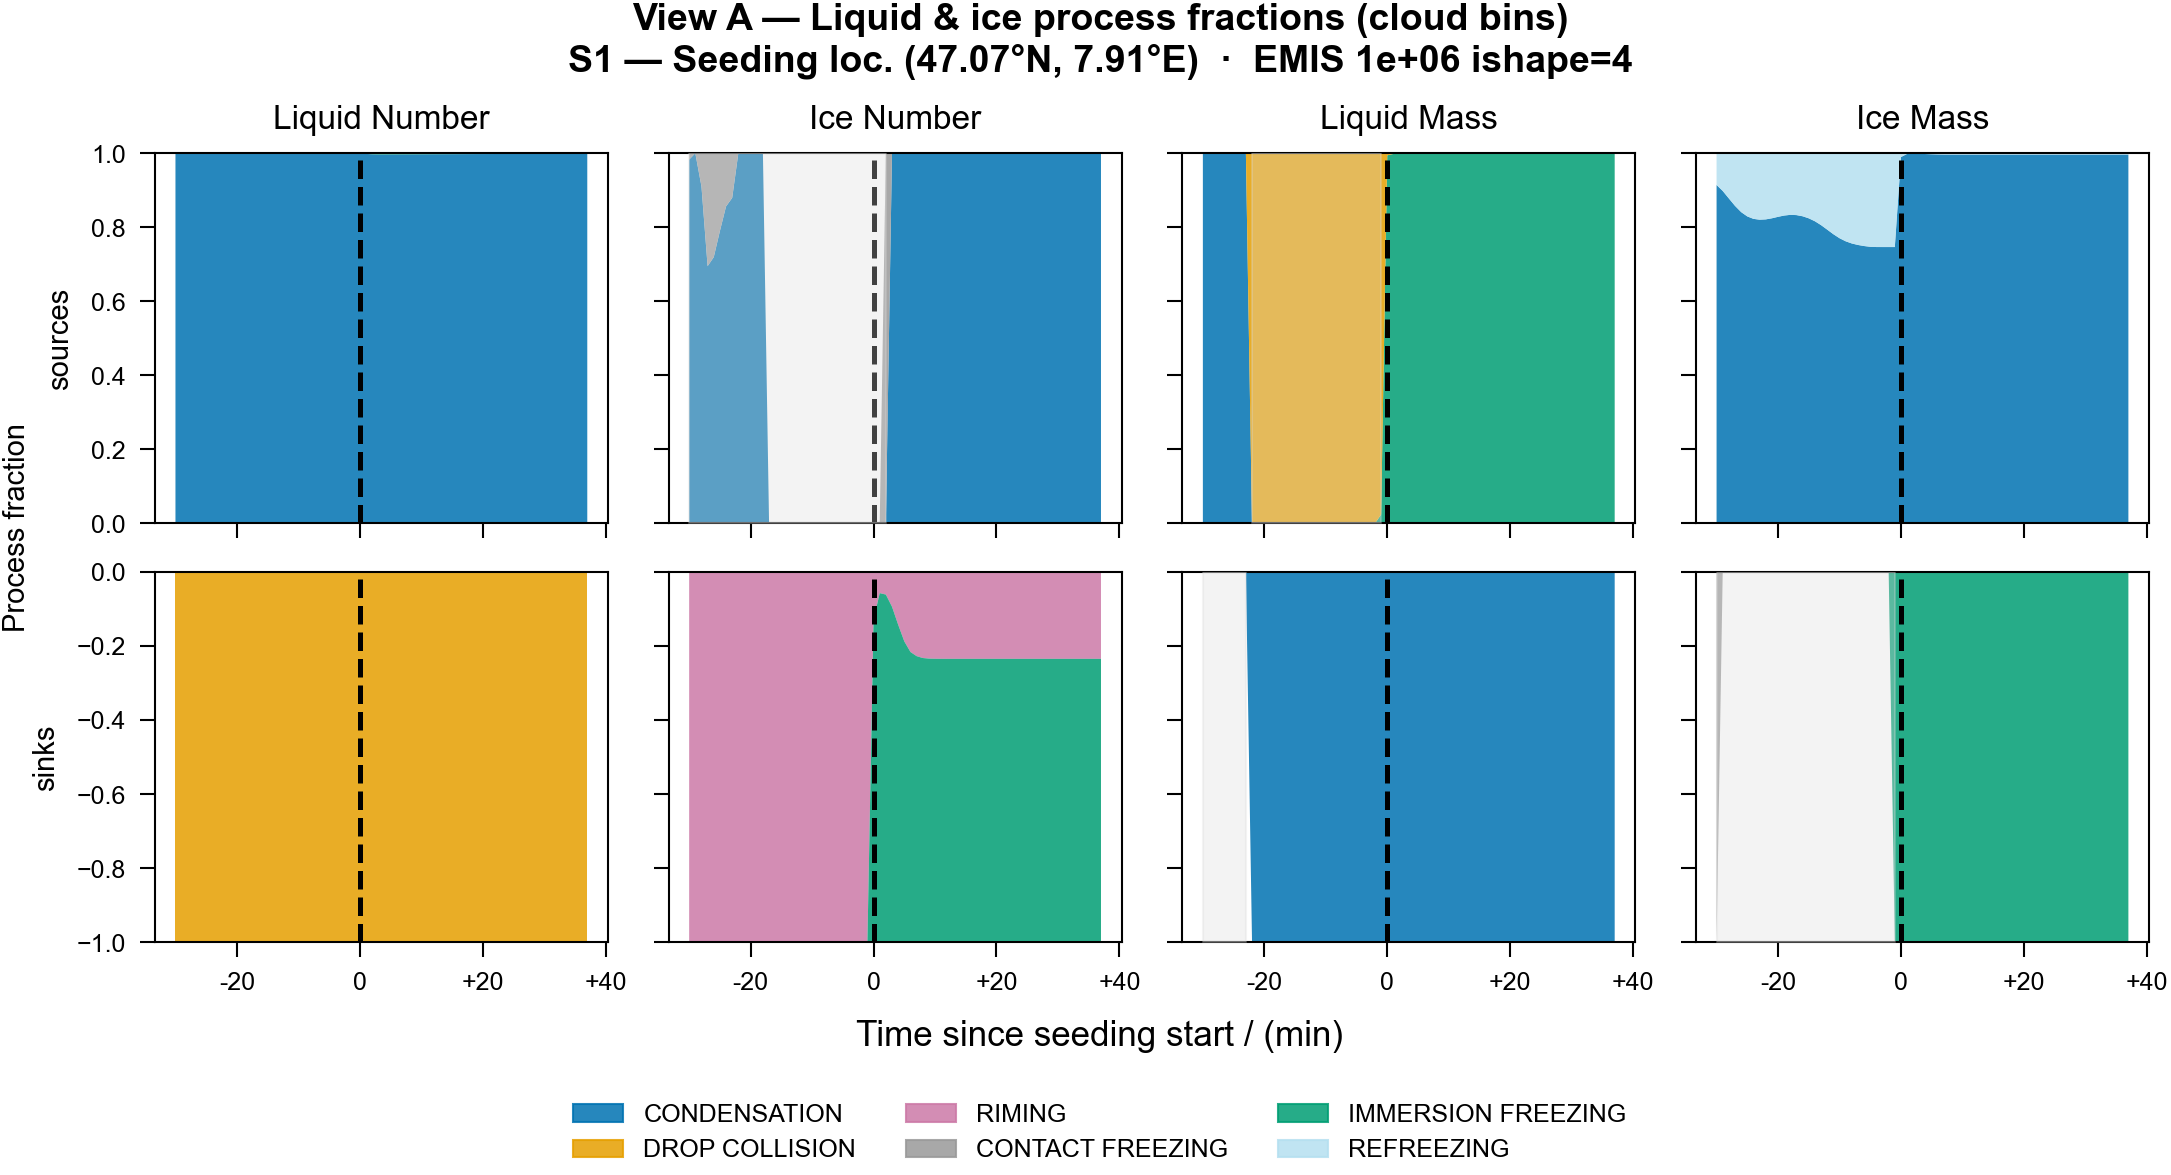

saved → ./stacked_area_liquid_ice_exp0_stn0.png


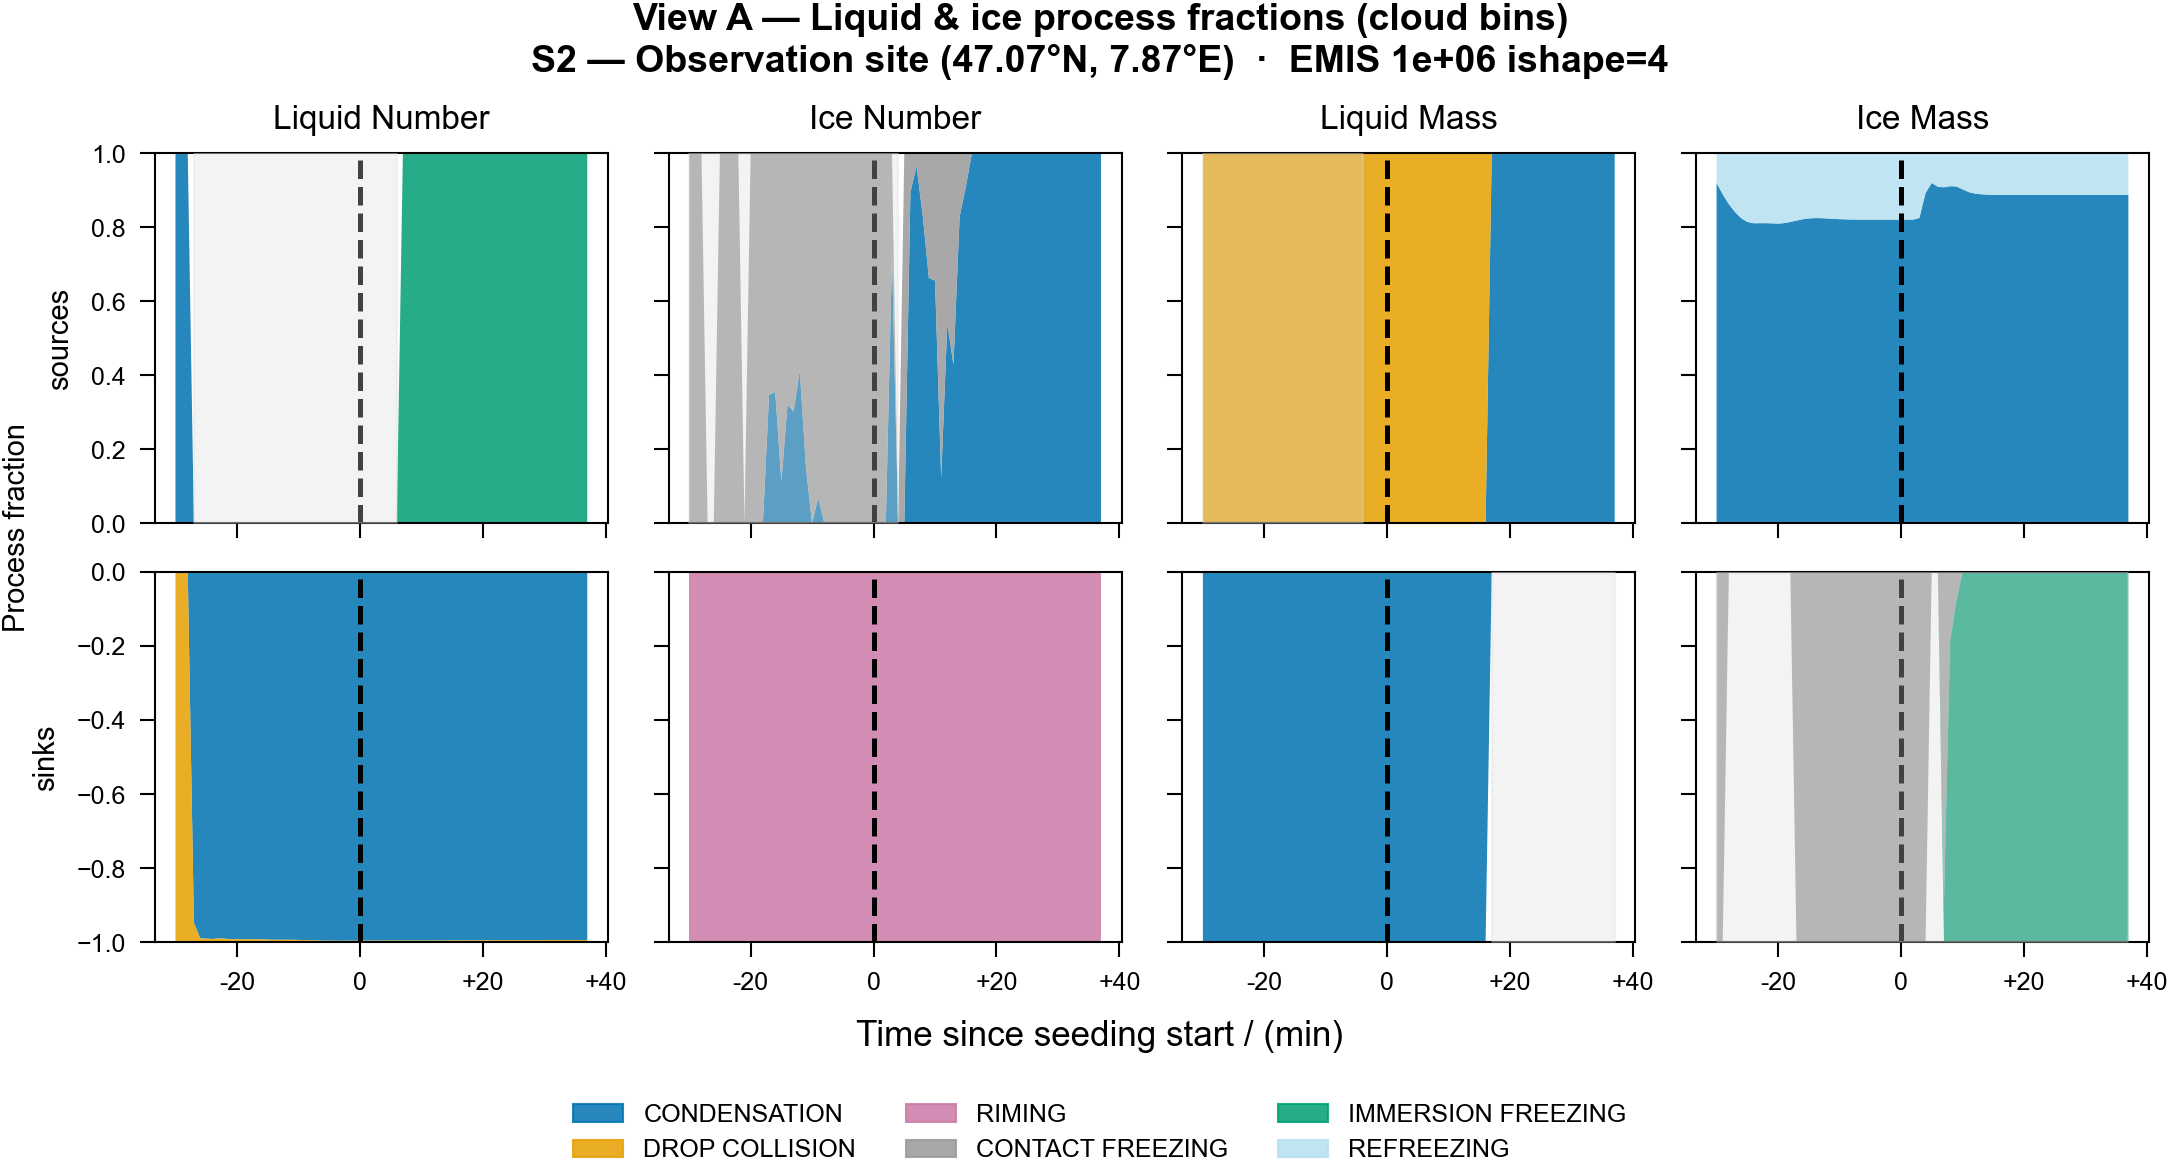

saved → ./stacked_area_liquid_ice_exp0_stn1.png


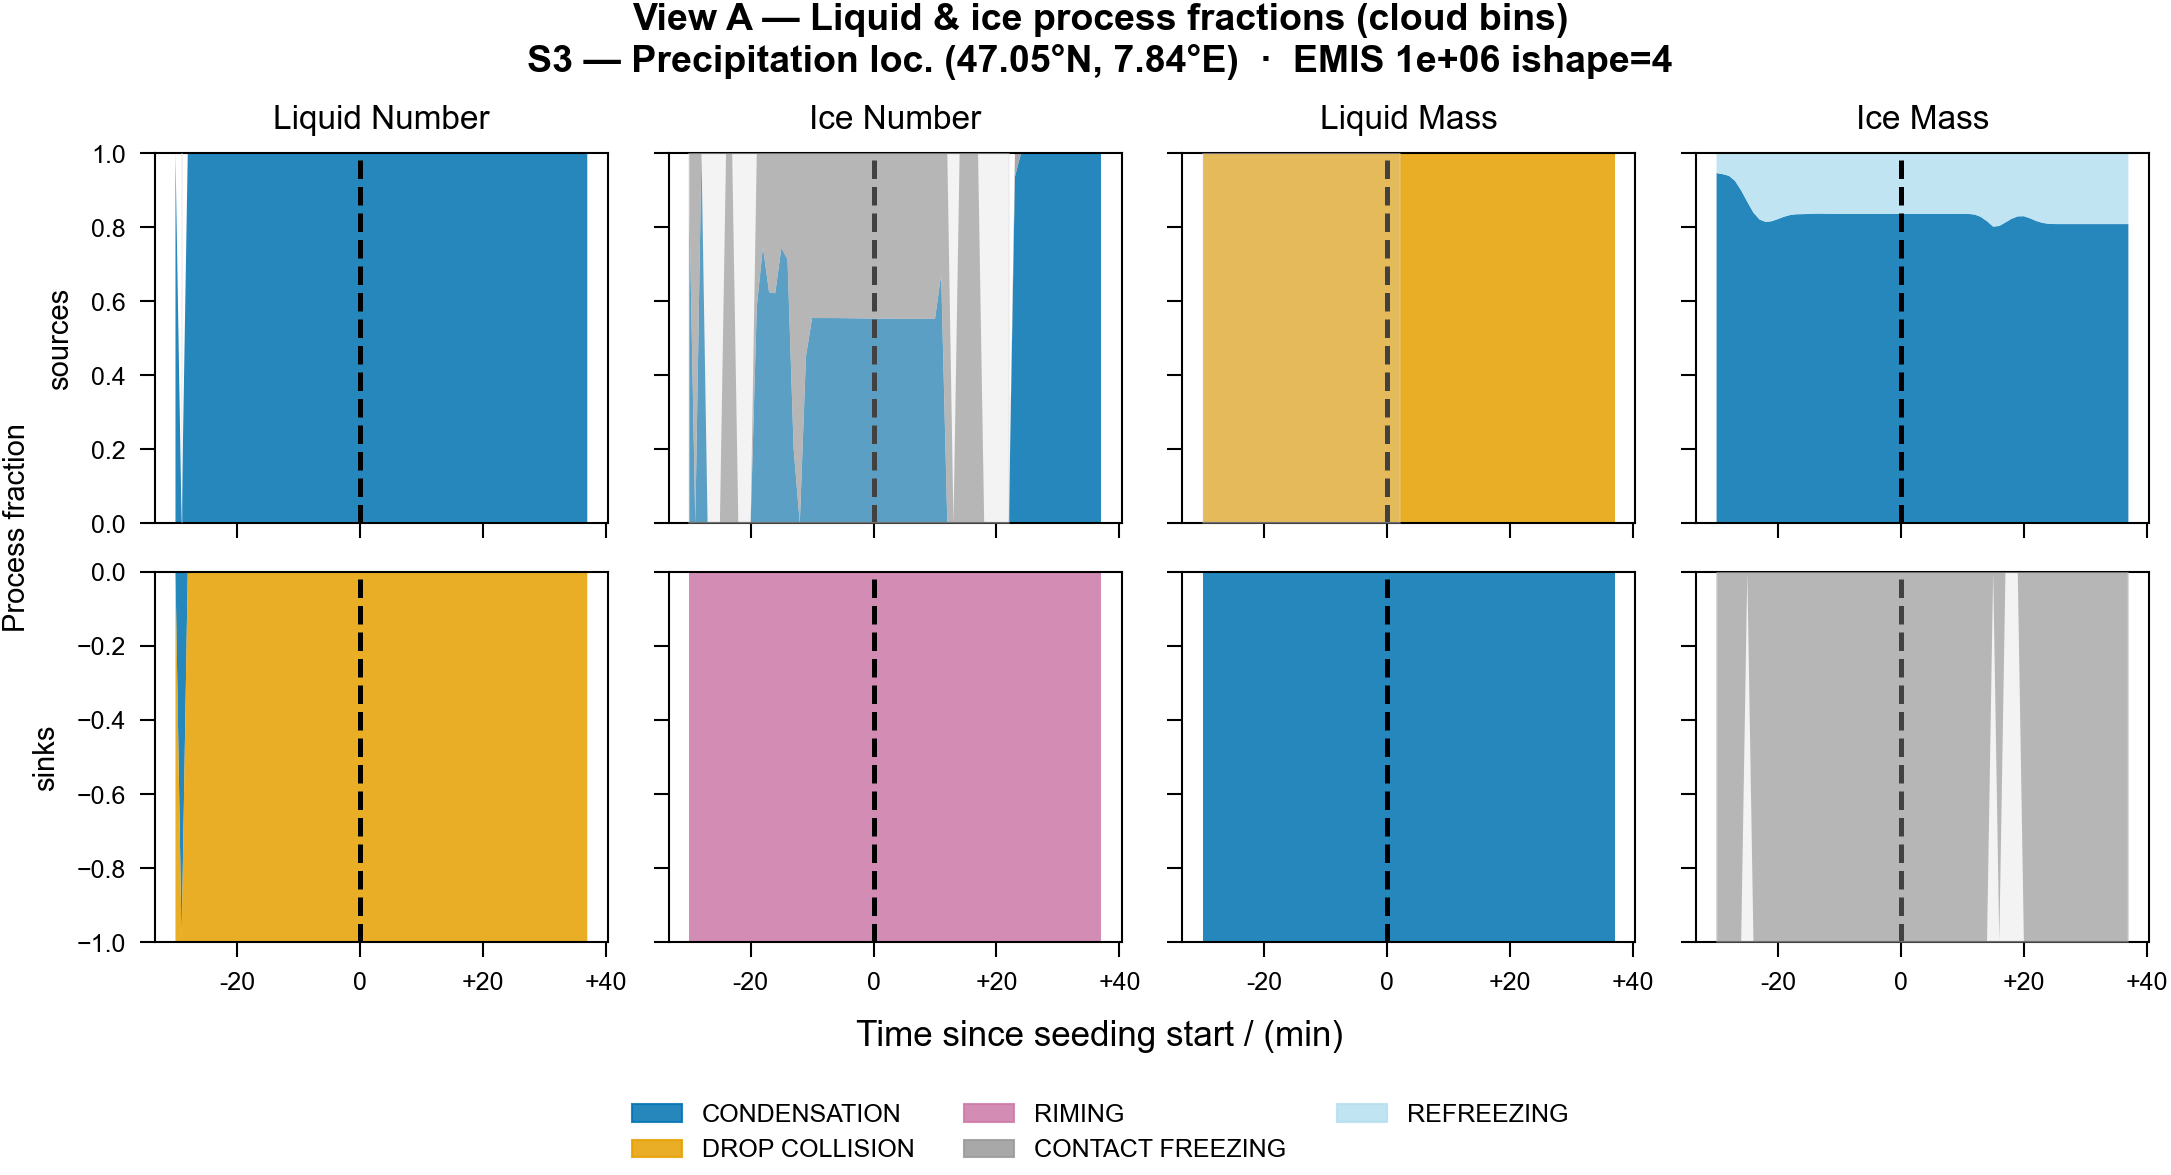

saved → ./stacked_area_liquid_ice_exp0_stn2.png


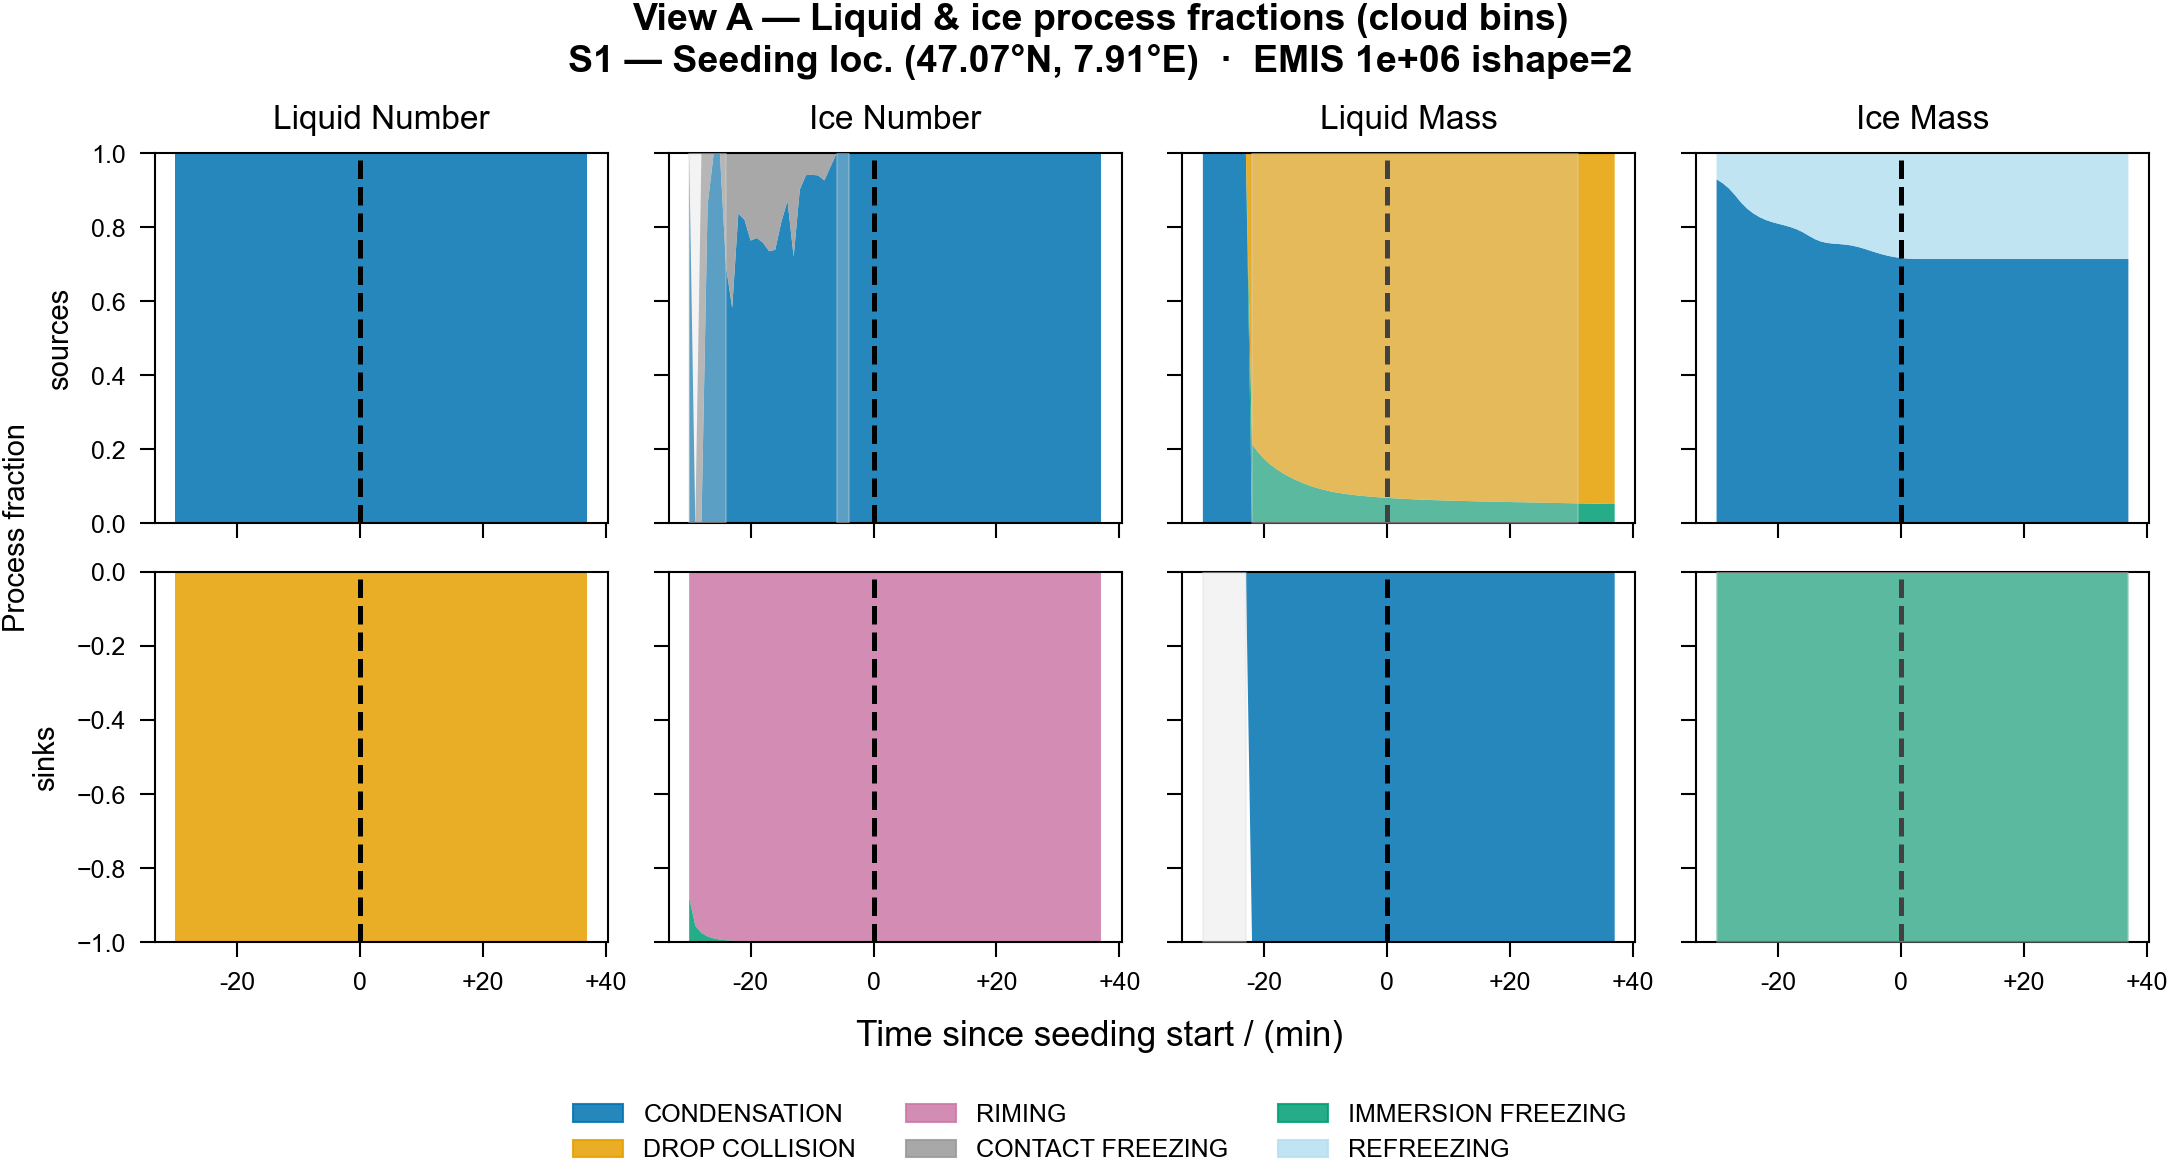

saved → ./stacked_area_liquid_ice_exp1_stn0.png


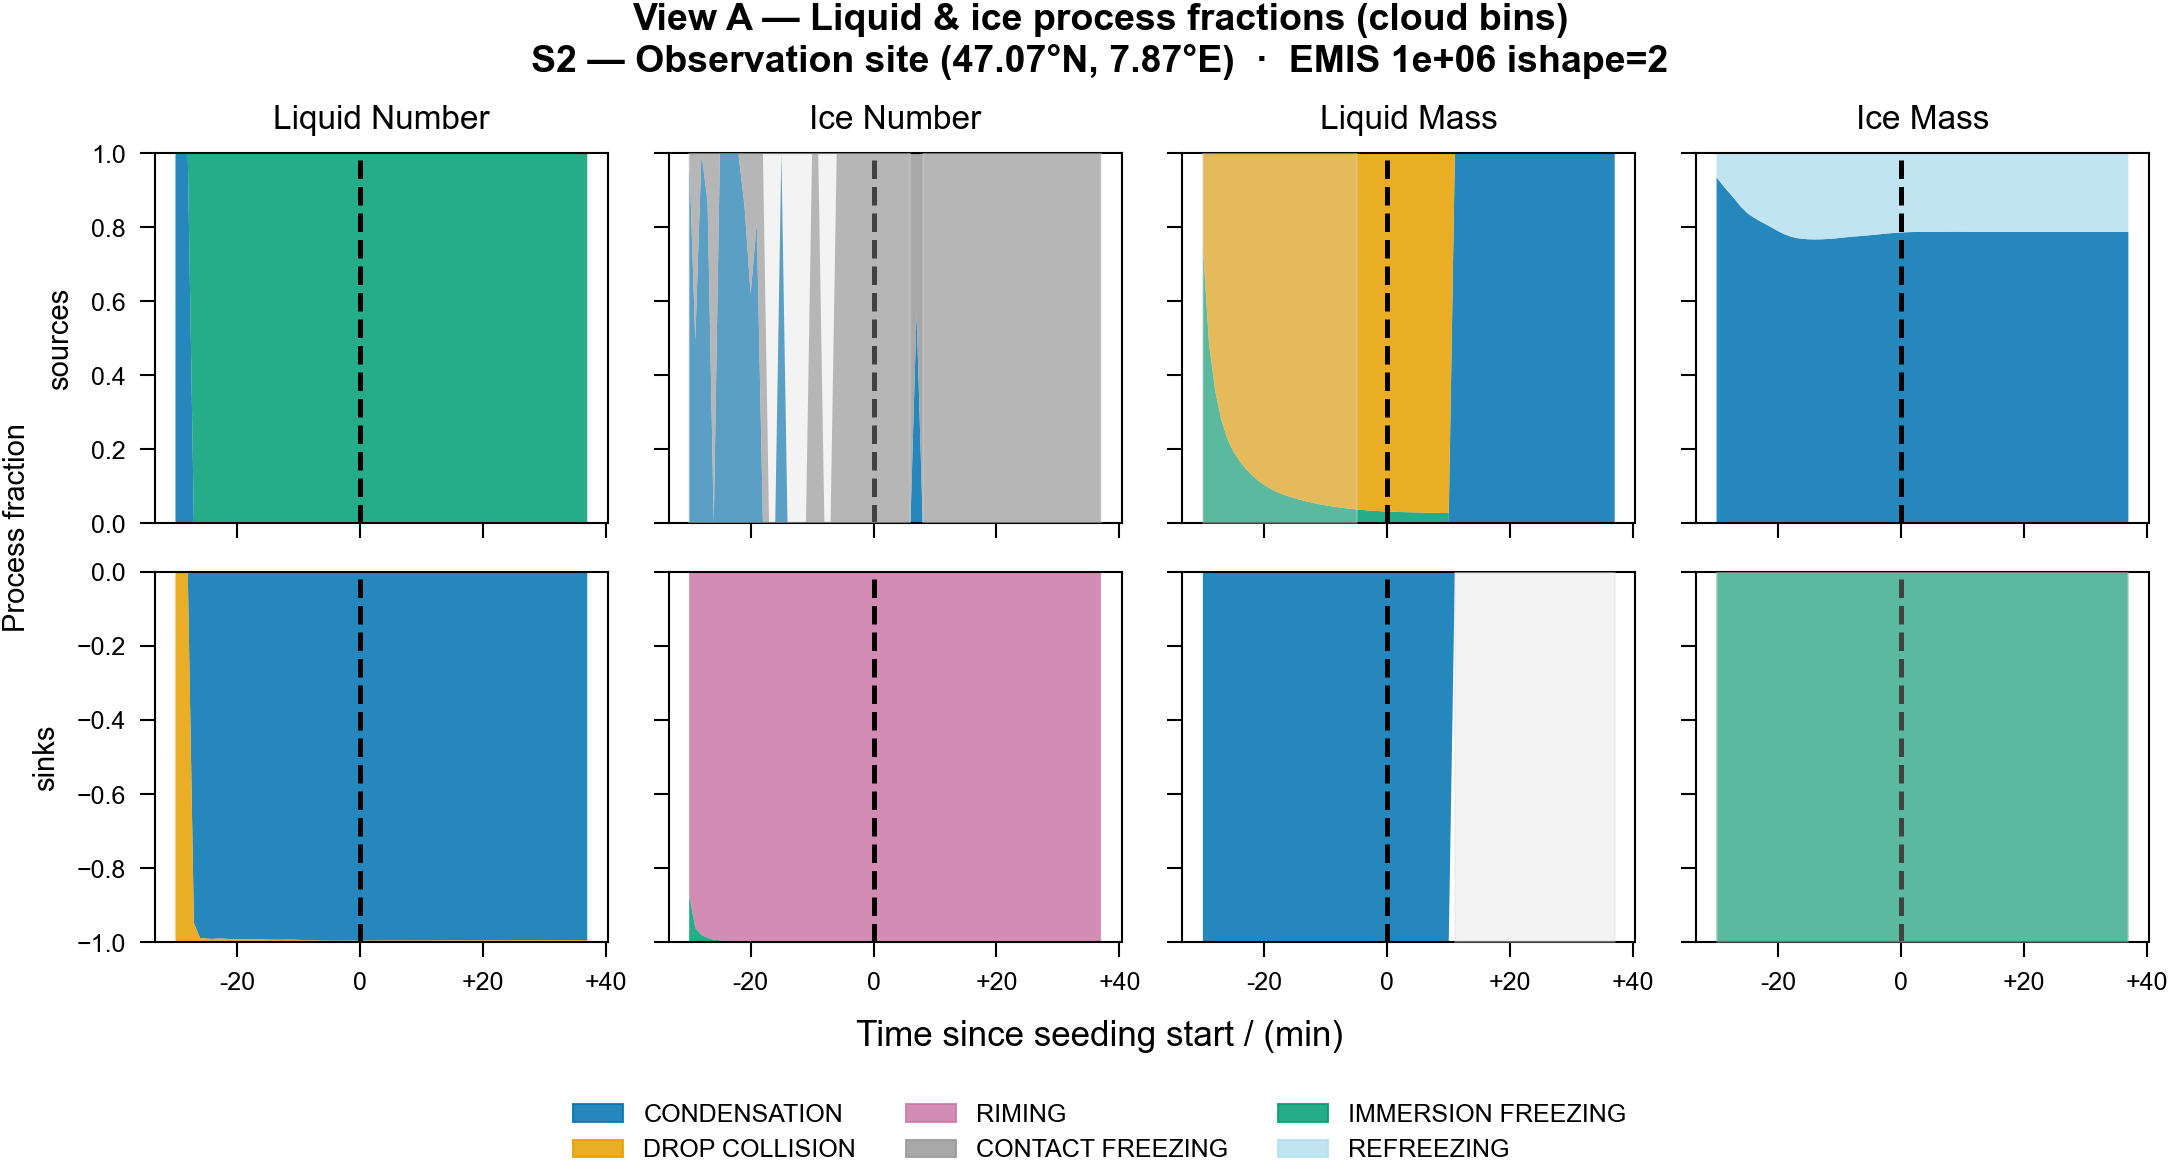

saved → ./stacked_area_liquid_ice_exp1_stn1.png


In [ ]:

if "rates_by_exp" in dir() and rates_by_exp:
    for eid in PLOT_EXP_IDS:
        R = rates_by_exp[eid]
        exp_label = R["exp_label"]
        for si in PLOT_STN_IDS:
            fig, axes = plot_stacked_area_liquid_ice(
                R["rates_N_liq"], R["rates_Q_liq"], R["rates_N_ice"], R["rates_Q_ice"], si=si
            )
            save_fig(fig, f"stacked_area_liquid_ice_exp{eid}_stn{si}", "png", "./")
else:
    fig, axes = plot_stacked_area_liquid_ice(rates_N_liq, rates_Q_liq, rates_N_ice, rates_Q_ice)
    save_fig(fig, "stacked_area_liquid_ice", "png", "./")

***View A — Fractional process budget over time.** Normalised stacked-area plots showing the temporal evolution of each microphysical process's fractional contribution to the total source (top panel) and total sink (bottom panel) budget. Rates are height-averaged and bin-summed over the respective spectral range (cloud bins 30–49 or precipitation bins 50–65), then time-coarsened to 1 min. A thin black line on the twin axis traces $\log_{10}$ of the total absolute rate to provide magnitude context; grey shading masks periods where the budget is physically negligible ($|Σ\,\mathrm{rate}| < 10^{-12}$). Seeding onset (12:30 UTC) is marked by a dashed vertical line. Six figures are produced — one for each combination of spectrum (liquid, ice, precipitation) and tendency kind (number, mass).*

---
## View B – Stacked bar charts: process budget by height level

Time-averaged absolute rates per process at each height level.
Left panel = sources, right panel = sinks.

In [ ]:
def _bars_height_prep(rates_dict, si, bar_fill=0.999):
    """Return (hl, bar_h, pos_vals, neg_vals, procs, colors) for one rates_dict."""
    procs = list(rates_dict.keys())
    colors = [proc_color(p) for p in procs]
    hl = rates_dict[procs[0]].isel(station=si).coords["height_level"].values[::-1]
    hl_s = np.sort(hl)
    if len(hl_s) > 1:
        edges = np.concatenate([
            [hl_s[0] - 0.5 * (hl_s[1] - hl_s[0])],
            0.5 * (hl_s[1:] + hl_s[:-1]),
            [hl_s[-1] + 0.5 * (hl_s[-1] - hl_s[-2])],
        ])
        bar_h = np.diff(edges) * bar_fill
    else:
        bar_h = np.array([20.0])
    pos_vals, neg_vals = {}, {}
    for p in procs:
        da = rates_dict[p].isel(station=si).mean(dim="time").compute()
        v = da.values
        pos_vals[p] = np.where(v > 0, v, 0)
        neg_vals[p] = np.where(v < 0, np.abs(v), 0)
    return hl, bar_h, pos_vals, neg_vals, procs, colors


def plot_stacked_bars_height(rates_dict, unit_label, spectrum_label, si=STN_IDX,
                             bar_fill: float = 0.999):
    """Single spectrum: two panels (sources, sinks). bar_fill: fraction of level bin width."""
    hl, bar_h, pos_vals, neg_vals, procs, colors = _bars_height_prep(rates_dict, si, bar_fill)
    fig, axes = plt.subplots(1, 2, figsize=(FULL_COL_IN, 110 * MM), sharey=True,
                             constrained_layout=True)
    for ax, vals, title in [(axes[0], pos_vals, "Sources (positive)"),
                            (axes[1], neg_vals, "Sinks (|negative|)")]:
        left = np.zeros_like(hl, dtype=float)
        for p, c in zip(procs, colors):
            ax.barh(hl, vals[p], left=left, color=c, label=p,
                    edgecolor="white", linewidth=0.3, height=bar_h)
            left += vals[p]
        ax.set_xlabel(f"|Rate| [{unit_label}]")
        ax.set_title(title)
    axes[0].set_ylabel("Height [m]")
    axes[1].legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False)
    fig.suptitle(f"View B — {spectrum_label} budget by height [{unit_label}]\n"
                 f"{stn_label(si)}  (exp {exp_label})", fontweight="bold")
    plt.show()


def plot_stacked_bars_height_all(rates_N_liq, rates_Q_liq, rates_N_ice, rates_Q_ice,
                                 si=STN_IDX, bar_fill=0.999):
    """Single figure: 4 rows (Liquid N, Liquid Q, Ice N, Ice Q), 2 cols (Sinks | Sources).
    Sinks on the left with inverted x-axis; sources on the right."""
    import matplotlib.patches as mpatches
    rows = [
        (rates_N_liq, unit_N, "Liquid number"),
        (rates_Q_liq, unit_Q, "Liquid mass"),
        (rates_N_ice, unit_N, "Ice number"),
        (rates_Q_ice, unit_Q, "Ice mass"),
    ]
    preps = [_bars_height_prep(rd, si, bar_fill) for rd, _, _ in rows]
    hl = preps[0][0]
    bar_h = preps[0][1]
    all_procs = set()
    for _, _, _, _, procs, _ in preps:
        all_procs.update(procs)
    procs_ordered = [p for p in PROC_COLORS if p in all_procs]

    fig, axes = plt.subplots(4, 2, figsize=(FULL_COL_IN//2, min(4 * 52 * MM, MAX_H_IN)),
                             sharey=True, constrained_layout=True)
    for i, (rates_dict, unit_label, row_title) in enumerate(rows):
        _, _, pos_vals, neg_vals, procs, colors = preps[i]
        ax_sink, ax_src = axes[i, 0], axes[i, 1]
        # Sinks (left): stack left-to-right from 0, then invert x so bars extend leftward
        left = np.zeros_like(hl, dtype=float)
        for p in procs:
            ax_sink.barh(hl, neg_vals[p], left=left, color=proc_color(p), label=p,
                         edgecolor="white", linewidth=0.3, height=bar_h)
            left += neg_vals[p]
        ax_sink.invert_xaxis()
        ax_sink.set_xlabel(f"|Rate| [{unit_label}]" if i == 3 else "")
        ax_sink.set_title("Sinks" if i == 0 else "")
        # Sources (right)
        left = np.zeros_like(hl, dtype=float)
        for p in procs:
            ax_src.barh(hl, pos_vals[p], left=left, color=proc_color(p), label=p,
                        edgecolor="white", linewidth=0.3, height=bar_h)
            left += pos_vals[p]
        ax_src.set_xlabel(f"|Rate| [{unit_label}]" if i == 3 else "")
        ax_src.set_title("Sources" if i == 0 else "")
    axes[0, 0].set_ylabel("Height [m]\nLiquid number", fontsize="small")
    axes[1, 0].set_ylabel("Liquid mass", fontsize="small")
    axes[2, 0].set_ylabel("Ice number", fontsize="small")
    axes[3, 0].set_ylabel("Ice mass", fontsize="small")
    handles = [mpatches.Patch(color=proc_color(p), label=p.replace("_", " "), alpha=0.85)
               for p in procs_ordered]
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.02),
               frameon=False, ncol=min(len(procs_ordered), 6))
    fig.supxlabel("|Rate| (sinks left, sources right)")
    fig.suptitle(f"View B — Budget by height (cloud bins)\n{stn_label(si)}  ·  {exp_label}",
                 fontweight="bold")
    plt.show()
    return fig, axes


if "rates_by_exp" in dir() and rates_by_exp:
    for eid in PLOT_EXP_IDS:
        R = rates_by_exp[eid]
        exp_label = R["exp_label"]
        for si in PLOT_STN_IDS:
            plot_stacked_bars_height_all(
                R["rates_N_liq"], R["rates_Q_liq"], R["rates_N_ice"], R["rates_Q_ice"], si=si
            )
else:
    plot_stacked_bars_height_all(rates_N_liq, rates_Q_liq, rates_N_ice, rates_Q_ice)

***View B — Vertical budget profile.** Side-by-side horizontal stacked-bar charts showing the time-averaged absolute microphysical rates at each model height level. The left panel shows source (positive) contributions and the right panel shows sink (|negative|) contributions, both bin-summed over the respective spectral range. Bar thickness is proportional to the model-level spacing. Six figures are produced — one for each combination of spectrum (liquid, ice, precipitation) and tendency kind (number, mass).*

---
## View C – Dominant process + confidence (time × height)

Left: categorical map coloured by the process with the largest |rate|.
Right: **dominance confidence** = fraction of total |rate| that the
winning process accounts for (1 = monopoly, ~0.2 = contested).

In [ ]:
def plot_dominance(rates_dict, unit_label, spectrum_label, si=STN_IDX):
    procs = list(rates_dict.keys())
    n_procs = len(procs)
    colors = [proc_color(p) for p in procs]

    da0 = rates_dict[procs[0]].isel(station=si)
    time_vals = da0.coords["time"].values
    hl_vals = da0.coords["height_level"].values

    # (n_procs, time, height_level)
    abs_stack = np.stack([np.abs(rates_dict[p].isel(station=si).values)
                          for p in procs], axis=0)

    total = np.nansum(abs_stack, axis=0)
    dominant_idx = np.nanargmax(abs_stack, axis=0).astype(float)
    confidence = np.where(total > 0,
                          np.nanmax(abs_stack, axis=0) / total,
                          np.nan)

    # mask cells with zero activity OR negligible total rate
    insignificant = (np.all(np.isnan(abs_stack) | (abs_stack == 0), axis=0)
                     | (total < RATE_FLOOR))
    dominant_idx[insignificant] = np.nan
    confidence[insignificant] = np.nan

    cmap_cat = mcolors.ListedColormap(colors[:n_procs])
    norm_cat = mcolors.BoundaryNorm(np.arange(-0.5, n_procs), n_procs)

    fig, axes = plt.subplots(1, 2, figsize=(FULL_COL_IN, 60 * MM), constrained_layout=True,
                             gridspec_kw={"width_ratios": [3, 3]})

    # Left: dominant process
    ax = axes[0]
    pcm = ax.pcolormesh(time_vals, hl_vals, dominant_idx.T,
                        cmap=cmap_cat, norm=norm_cat, shading="auto")
    ax.axvline(SEED_START, color="k", linewidth=0.8, linestyle="--")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.set_ylabel("Height [m]")
    ax.set_xlabel("Time [UTC]")
    ax.set_title("Dominant process")
    cbar = fig.colorbar(pcm, ax=ax, ticks=np.arange(n_procs))
    cbar.ax.set_yticklabels(procs)

    # Right: confidence
    ax2 = axes[1]
    pcm2 = ax2.pcolormesh(time_vals, hl_vals, confidence.T,
                          cmap="YlOrRd", vmin=0, vmax=1, shading="auto")
    ax2.axvline(SEED_START, color="k", linewidth=0.8, linestyle="--")
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax2.set_ylabel("Height [m]")
    ax2.set_xlabel("Time [UTC]")
    ax2.set_title("Dominance confidence (fraction of total |rate|)")
    fig.colorbar(pcm2, ax=ax2, label="Confidence")

    fig.suptitle(f"View C — {spectrum_label} dominance [{unit_label}]\n"
                 f"{stn_label(si)}  (exp {exp_label})",
                 fontweight="bold")
    plt.show()


if "rates_by_exp" in dir() and rates_by_exp:
    for eid in PLOT_EXP_IDS:
        R = rates_by_exp[eid]
        exp_label = R["exp_label"]
        for si in PLOT_STN_IDS:
            plot_dominance(R["rates_N_liq"], R["unit_N"], "Liquid – number (cloud bins)", si=si)
            plot_dominance(R["rates_Q_liq"], R["unit_Q"], "Liquid – mass (cloud bins)", si=si)
            plot_dominance(R["rates_N_ice"], R["unit_N"], "Ice – number (cloud bins)", si=si)
            plot_dominance(R["rates_Q_ice"], R["unit_Q"], "Ice – mass (cloud bins)", si=si)
            plot_dominance(R["rates_N_pcp"], R["unit_N"], "Precip – number (bins 50–65)", si=si)
            plot_dominance(R["rates_Q_pcp"], R["unit_Q"], "Precip – mass (bins 50–65)", si=si)
else:
    plot_dominance(rates_N_liq, unit_N, "Liquid – number (cloud bins)")
    plot_dominance(rates_Q_liq, unit_Q, "Liquid – mass (cloud bins)")
    plot_dominance(rates_N_ice, unit_N, "Ice – number (cloud bins)")
    plot_dominance(rates_Q_ice, unit_Q, "Ice – mass (cloud bins)")
    plot_dominance(rates_N_pcp, unit_N, "Precip – number (bins 50–65)")
    plot_dominance(rates_Q_pcp, unit_Q, "Precip – mass (bins 50–65)")

***View C — Dominant-process and confidence maps.** Two-panel time–height diagrams for each spectrum and tendency kind. (Left) Categorical colour map showing the microphysical process with the largest absolute rate in each time–height cell (bin-summed over the respective spectral range). (Right) Dominance confidence, defined as the winning process's share of the total absolute rate (1 = monopoly, $\sim$0.2 = strongly contested). Cells with negligible total rate ($< 10^{-12}$) are masked. Seeding onset is marked by a dashed vertical line. Six figures are produced — one for each combination of spectrum (liquid, ice, precipitation) and tendency kind (number, mass).*

---
## View D – Bin-resolved spectral budget waterfall

For selected height levels and a short time window, show each process
rate as a function of droplet/crystal diameter.  This is the only view
that reveals *where in the size spectrum* each process acts.

In [ ]:
# Select snapshot parameters — heights in metres (nearest-match selection)
# Seeding starts at 12:30 UTC; pick a window shortly after onset.
HEIGHT_SEL_M = [900, 1000, 1100, 1200]
TIME_WINDOW = slice(np.datetime64("2023-01-25T12:30:00"),
                    np.datetime64("2023-01-25T12:40:00"))

In [ ]:
# Spectral bin ranges for View D columns.
# Each entry: (bin_slice, column_label, warm_rates_key, frozen_rates_key)
# LBB and CBB are identical slices (both 30–49) but differ in spectrum:
#   col 0 = warm (W) processes over LBB  →  cloud-droplet budget
#   col 1 = frozen (F) processes over CBB → ice-crystal budget
#   col 2 = both spectra over PBB         → precipitation budget
# Using spectrum-separated dicts avoids showing duplicate panels.
SPEC_COLUMNS = [
    (LBB, "Cloud droplets (30–50)",  "W"),
    (CBB, "Ice crystals (30–50)",    "F"),
    (PBB, "Precip / snow (51–66)",   None),   # None = both spectra
]


def plot_spectral_waterfall(spec_rates_W, spec_rates_F, unit_label, kind_label,
                            height_sel_m=HEIGHT_SEL_M,
                            time_window=TIME_WINDOW,
                            si=STN_IDX):
    """View D — spectral budget per process, styled after 03-plot-psd-waterfall.

    spec_rates_W / spec_rates_F : dicts of bin-resolved DataArrays for warm and
    frozen spectra respectively.  Each column uses the appropriate spectrum dict
    so LBB (warm) and CBB (frozen) panels show distinct physics.
    """
    from matplotlib.ticker import FuncFormatter

    # Merge W+F keys for the precipitation column (both spectra)
    spec_rates_both = {
        p: spec_rates_W[p] for p in spec_rates_W
    }
    for p, da in spec_rates_F.items():
        spec_rates_both[p] = spec_rates_both[p] + da if p in spec_rates_both else da

    _dicts = {"W": spec_rates_W, "F": spec_rates_F, None: spec_rates_both}

    n_hl = len(height_sel_m)
    n_cols = len(SPEC_COLUMNS)

    fig, axes = plt.subplots(n_hl, n_cols,
                             figsize=(FULL_COL_IN, min(n_hl * 60 * MM, MAX_H_IN)),
                             constrained_layout=True)
    if n_hl == 1:
        axes = axes[np.newaxis, :]
    if n_cols == 1:
        axes = axes[:, np.newaxis]

    for row, h_m in enumerate(height_sel_m[::-1]):
        for col, (bin_slice, spec_label, spectrum_key) in enumerate(SPEC_COLUMNS):
            ax = axes[row, col]
            spec_rates = _dicts[spectrum_key]
            procs = list(spec_rates.keys())
            colors = [proc_color(p) for p in procs]
            any_data = False

            for p, c in zip(procs, colors):
                da = spec_rates[p].isel(station=si).sel(
                    height_level=h_m, method="nearest")
                actual_h = float(da.coords["height_level"])
                da_t = da.sel(time=time_window)
                if da_t.sizes["time"] == 0:
                    continue
                vals = da_t.mean(dim="time").isel(bins=bin_slice).values
                d = diameter_um[bin_slice]
                if np.any(np.isfinite(vals) & (vals != 0)):
                    ax.fill_between(d, 0, vals, step="mid",
                                    facecolor=(*mcolors.to_rgb(c), 0.25),
                                    edgecolor=(*mcolors.to_rgb(c), 0.8),
                                    linewidth=0.7, label=p)
                    ax.plot(d, vals, color=c, linewidth=0.8,
                            drawstyle="steps-mid")
                    any_data = True

            ax.set_xscale("log")
            ax.set_yscale("symlog", linthresh=1e-12, linscale=0.5)
            ax.axhline(0, color="grey", linewidth=0.4, linestyle="--")

            ax.grid(True, which="major", linestyle="--", linewidth=0.25,
                    color="k", alpha=0.5)
            ax.grid(True, which="minor", linestyle=":", linewidth=0.15,
                    color="k", alpha=0.3)
            ax.set_axisbelow(True)
            ax.tick_params(which="both", direction="out")
            ax.xaxis.set_major_formatter(FuncFormatter(
                lambda x, _: f"{x:g}"))

            if row == n_hl - 1:
                ax.set_xlabel("Diameter [µm]")
            if col == 0:
                ax.set_ylabel(f"Rate [{unit_label}]")

            panel_txt = f"{spec_label} — {actual_h:.0f} m"
            ax.text(0.02, 0.96, panel_txt, transform=ax.transAxes,
                    ha="left", va="top", fontsize=8, fontweight="bold",
                    bbox=dict(facecolor="white", edgecolor="0.3",
                              alpha=0.85, boxstyle="round,pad=0.25"))

            if not any_data:
                ax.text(0.5, 0.5, "no signal", transform=ax.transAxes,
                        ha="center", va="center", color="grey")

    axes[0, -1].legend(loc="upper left", bbox_to_anchor=(1.01, 1),
                       frameon=False)
    tw_str = (str(time_window.start)[:16] + " – " + str(time_window.stop)[:16])
    fig.suptitle(f"View D — {kind_label} spectral budget [{unit_label}]\n"
                 f"{stn_label(si)}  (exp {exp_label})  |  {tw_str}",
                 fontweight="bold")
    plt.show()


if "rates_by_exp" in dir() and rates_by_exp:
    for eid in PLOT_EXP_IDS:
        R = rates_by_exp[eid]
        exp_label = R["exp_label"]
        for si in PLOT_STN_IDS:
            plot_spectral_waterfall(R["spec_rates_N_W"], R["spec_rates_N_F"], R["unit_N"], "Number", si=si)
            plot_spectral_waterfall(R["spec_rates_Q_W"], R["spec_rates_Q_F"], R["unit_Q"], "Mass", si=si)
else:
    plot_spectral_waterfall(spec_rates_N_W, spec_rates_N_F, unit_N, "Number")
    plot_spectral_waterfall(spec_rates_Q_W, spec_rates_Q_F, unit_Q, "Mass")

***View D — Bin-resolved spectral budget waterfall.** Time-averaged microphysical process rates as a function of equivalent particle diameter for a short post-seeding window (12:30–12:40 UTC). Each row corresponds to a selected model height level (decreasing from top to bottom); each column shows a different spectral range (cloud droplets bins 30–49, ice crystals bins 30–49, precipitation bins 50–65). Individual process rates are plotted as filled step profiles (positive = source, negative = sink) with a symlog y-axis to resolve rates spanning many orders of magnitude. This is the only view that preserves the full spectral (diameter) axis and reveals where in the size distribution each process acts. Two figures are produced — one for number tendencies and one for mass tendencies.*

---
## View E – Hovmöller total-rate heatmap with dominant-process overlay

Combines the temporal and vertical dimensions in a single compact plot.
Colour shows **log₁₀(Σ|rate|)** (total absolute rate over all processes),
overlaid with semi-transparent contours for the **dominant process** per
time–height cell.  One panel per station (3 columns), one figure per
bin-range × kind combination.  Time is coarsened to `TIME_COARSEN`.

In [ ]:
def plot_hovmoller_budget(rates_dict, unit_label, spectrum_label):
    """View E — Hovmöller total-rate heatmap + dominant-process overlay."""
    from matplotlib.patches import Patch

    procs = list(rates_dict.keys())
    colors = [proc_color(p) for p in procs]

    fig, axes = plt.subplots(1, n_stations, figsize=(FULL_COL_IN, 65 * MM),
                             constrained_layout=True, sharey=True)
    if n_stations == 1:
        axes = [axes]

    im = None
    for si, ax in enumerate(axes):
        # Coarsen time, compute per-process absolute rates
        series = {p: rates_dict[p].isel(station=si)
                     .resample(time=TIME_COARSEN).mean().compute()
                  for p in procs}
        time_vals = series[procs[0]].time.values
        height_vals = series[procs[0]].height_level.values

        # Ensure height is monotonically increasing for contourf
        h_order = np.argsort(height_vals)
        height_sorted = height_vals[h_order]

        t_num = mdates.date2num(time_vals)

        abs_rates = np.array([np.abs(series[p].values[:, h_order])
                              for p in procs])          # (n_proc, time, height)
        total_abs = abs_rates.sum(axis=0)                 # (time, height)
        dominant = np.argmax(abs_rates, axis=0)           # (time, height)

        log_total = np.log10(np.where(total_abs > RATE_FLOOR,
                                      total_abs, np.nan))

        im = ax.pcolormesh(t_num, height_sorted, log_total.T,
                           cmap="inferno_r", shading="nearest", alpha=0.85, vmin=np.nanpercentile(log_total, 0.5))


        # Dominant-process semi-transparent overlay + boundary lines
        for ip, c in enumerate(colors):
            mask = (dominant == ip).astype(float)
            if mask.max() < 0.5:
                continue
            ax.contourf(t_num, height_sorted, mask.T,
                        levels=[0.5, 1.5], colors=[c], alpha=0.7, linewidths=.5)
            ax.contour(t_num, height_sorted, mask.T, alpha=0.9,
                       levels=[0.5], colors=[c], linewidths=1.)

        ax.axvline(mdates.date2num(SEED_START), color="w", lw=0.8,
                   ls="--", zorder=5)
        ax.set_title(stn_label(si))
        ax.set_xlabel("Time [UTC]")
        if si == 0:
            ax.set_ylabel("Height [m]")
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

    if im is not None:
        fig.colorbar(im, ax=list(axes),
                     label=f"log$_{{10}}$(Σ|rate|) [{unit_label}]",
                     shrink=0.8, pad=0.02)

    handles = [Patch(facecolor=c, alpha=0.5, edgecolor=c, label=p)
               for p, c in zip(procs, colors)]
    fig.legend(handles=handles, loc="lower center",
               ncol=min(6, len(procs)),
               bbox_to_anchor=(0.5, -0.06))

    fig.suptitle(f"View E — {spectrum_label} Hovmöller [{unit_label}]\n"
                 f"(exp {exp_label})",
                 fontweight="bold")
    plt.show()


if "rates_by_exp" in dir() and rates_by_exp:
    for eid in PLOT_EXP_IDS:
        R = rates_by_exp[eid]
        exp_label = R["exp_label"]
        plot_hovmoller_budget(R["rates_N_liq"], R["unit_N"], "Liquid – number (cloud bins)")
        plot_hovmoller_budget(R["rates_Q_liq"], R["unit_Q"], "Liquid – mass (cloud bins)")
        plot_hovmoller_budget(R["rates_N_ice"], R["unit_N"], "Ice – number (cloud bins)")
        plot_hovmoller_budget(R["rates_Q_ice"], R["unit_Q"], "Ice – mass (cloud bins)")
        plot_hovmoller_budget(R["rates_N_pcp"], R["unit_N"], "Precip – number (bins 50–65)")
        plot_hovmoller_budget(R["rates_Q_pcp"], R["unit_Q"], "Precip – mass (bins 50–65)")
else:
    plot_hovmoller_budget(rates_N_liq, unit_N, "Liquid – number (cloud bins)")
    plot_hovmoller_budget(rates_Q_liq, unit_Q, "Liquid – mass (cloud bins)")
    plot_hovmoller_budget(rates_N_ice, unit_N, "Ice – number (cloud bins)")
    plot_hovmoller_budget(rates_Q_ice, unit_Q, "Ice – mass (cloud bins)")
    plot_hovmoller_budget(rates_N_pcp, unit_N, "Precip – number (bins 50–65)")
    plot_hovmoller_budget(rates_Q_pcp, unit_Q, "Precip – mass (bins 50–65)")

***View E — Hovmöller total-rate heatmap with dominant-process overlay.** Time–height cross-sections of the total absolute microphysical rate (log$_{10}$-scaled, inferno colour map) at each meteogram station (one panel per station). Semi-transparent coloured contours indicate which process contributes the largest absolute rate in each time–height cell; boundary lines mark the transitions between dominant regimes. Time is coarsened to 1 min to suppress sub-second noise. A dashed white line marks seeding onset (12:30 UTC). Six figures are produced — one for each combination of spectrum (liquid cloud-droplet, ice crystal, precipitation) and tendency kind (number, mass).*

---
## Summary table — time-integrated budget

For quick reference: total positive and negative contribution of each
process, integrated over time and height.

In [ ]:
# Available stat names for budget_summary(..., stat_names=...)
BUDGET_STAT_NAMES = ["Mean", "%pos"] #"Mean(+)", "Mean(-)", 

def budget_summary(rates_dict, label, station_ids=None, stat_names=None):
    """Print tables (Mean, Mean(+), Mean(-), %pos) with stations as columns.
    stat_names: which tables to print; default None = all (BUDGET_STAT_NAMES)."""
    procs = list(rates_dict.keys())
    n_st = rates_dict[procs[0]].sizes["station"]
    if station_ids is None:
        station_ids = list(range(n_st))
    st_short = [STATION_LABELS.get(si, "Stn" + str(si)).split(" — ")[0].strip() for si in station_ids]

    rows = []
    for p in procs:
        row = {"process": p}
        for si in station_ids:
            v = rates_dict[p].isel(station=si).values.ravel()
            v = v[np.isfinite(v)]
            row[si] = {
                "mean": np.mean(v) if v.size else np.nan,
                "mean_pos": np.mean(v[v > 0]) if np.any(v > 0) else 0.0,
                "mean_neg": np.mean(v[v < 0]) if np.any(v < 0) else 0.0,
                "frac_pos": np.mean(v > 0) if v.size else 0.0,
            }
        rows.append(row)

    def max_abs_mean(row):
        return max(abs(row[si]["mean"]) for si in station_ids)
    sorted_rows = sorted(rows, key=max_abs_mean, reverse=True)

    w = 12
    sep = "  "
    n_cols = 1 + len(station_ids)

    stats_list = [
        ("Mean", "mean", "{:12.3e}"),
        ("Mean(+)", "mean_pos", "{:12.3e}"),
        ("Mean(-)", "mean_neg", "{:12.3e}"),
        ("%pos", "frac_pos", "{:12.1%}"),
    ]
    to_show = stat_names if stat_names is not None else BUDGET_STAT_NAMES
    for stat_name, key, fmt in stats_list:
        if stat_name not in to_show:
            continue
        print("\n  --- " + label + "  |  " + stat_name + " ---")
        print("  " + "{:30s}".format("Process") + sep + sep.join(["{:>12s}".format(s) for s in st_short]))
        print("  " + "-" * 30 + sep + sep.join(["-" * w] * len(station_ids)))
        for r in sorted_rows:
            line = "  {:30s}".format(r["process"])
            for si in station_ids:
                line += sep + fmt.format(r[si][key])
            print(line)


budget_summary(rates_N_liq, "Liquid – number")
budget_summary(rates_Q_liq, "Liquid – mass")


In [ ]:

budget_summary(rates_N_ice, "Ice – number")
budget_summary(rates_Q_ice, "Ice – mass")


***Table — Time-integrated microphysical budget.** For each spectrum (liquid, ice) and tendency kind (number, mass), lists the time- and height-averaged net rate, mean positive (source) rate, mean negative (sink) rate, and fraction of grid cells with a positive tendency for every resolved microphysical process. Processes are sorted by decreasing absolute net rate. All rates are volumetric, converted from raw specific tendencies by multiplication with air density (see Unit conversion in the introduction).*